In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 设置绘图样式
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. 数据加载

In [26]:
# 配置路径
BASE_DIR = Path('/cnz/data/project/my-open-unlearning/saves/tvc_results')

def load_tofu_summary(dir_path):
    """加载TOFU_SUMMARY.json文件"""
    summary_file = dir_path / 'TOFU_SUMMARY.json'
    if summary_file.exists():
        with open(summary_file, 'r') as f:
            return json.load(f)
    return None

def parse_exp_name(exp_name):
    """从实验名称中提取参数"""
    parts = exp_name.split('_')
    info = {
        'model': None,
        'forget_split': None,
        'alpha': 1.0,
        'beta': 1.0,
        'filter_type': 'default'
    }
    
    # 解析模型和split
    if len(parts) >= 3:
        info['model'] = '_'.join(parts[1:3])  # phi-1_5
        info['forget_split'] = parts[3] if len(parts) > 3 else None
    
    # 解析alpha和beta
    for part in parts:
        if part.startswith('alpha'):
            info['alpha'] = float(part.replace('alpha', ''))
        elif part.startswith('beta'):
            info['beta'] = float(part.replace('beta', ''))
    
    # 解析filter类型
    if 'all' in parts and 'linear' in parts:
        info['filter_type'] = 'all_linear'
    elif 'mlp' in parts and 'only' in parts:
        info['filter_type'] = 'mlp_only'
    elif 'default' in parts:
        info['filter_type'] = 'default'
    
    return info

# 加载所有forget05实验的数据
data_records = []

for exp_dir in BASE_DIR.iterdir():
    if exp_dir.is_dir() and 'forget05' in exp_dir.name:
        summary = load_tofu_summary(exp_dir)
        if summary:
            exp_info = parse_exp_name(exp_dir.name)
            record = {
                'exp_name': exp_dir.name,
                **exp_info,
                **summary
            }
            data_records.append(record)

# 创建DataFrame
df = pd.DataFrame(data_records)

print(f"加载了 {len(df)} 个实验结果")
print(f"\n实验配置统计:")
print(f"- Filter类型: {df['filter_type'].unique()}")
print(f"- Alpha值: {sorted(df['alpha'].unique())}")
print(f"- Beta值: {sorted(df['beta'].unique())}")
df.head()

加载了 36 个实验结果

实验配置统计:
- Filter类型: ['all_linear' 'mlp_only' 'default']
- Alpha值: [np.float64(0.5), np.float64(0.8), np.float64(1.0)]
- Beta值: [np.float64(0.5), np.float64(0.8), np.float64(1.0), np.float64(1.2), np.float64(1.5), np.float64(2.0)]


,exp_name,model,forget_split,alpha,beta,filter_type,exact_memorization,extraction_strength,forget_Q_A_Prob,forget_Q_A_ROUGE,forget_quality,forget_truth_ratio,model_utility,privleak,retain_Q_A_Prob,retain_Q_A_ROUGE
0,tvc_phi-1_5_forget05_alpha0.5_beta1.2_all_line...,phi-1_5,forget05,0.5,1.2,all_linear,0.574199,0.047880,0.131334,0.338720,0.016258,0.572636,0.210285,-61.875575,0.485644,0.417502
1,tvc_phi-1_5_forget05_alpha0.5_beta1.5_mlp_only...,phi-1_5,forget05,0.5,1.5,mlp_only,0.649261,0.070257,0.229613,0.380610,0.000649,0.540979,0.226849,-85.366227,0.554283,0.465519
2,tvc_phi-1_5_forget05_alpha0.8_beta0.8_all_line...,phi-1_5,forget05,0.8,0.8,all_linear,0.568016,0.052371,0.119421,0.374024,0.628431,0.610661,0.400212,-24.494330,0.755921,0.563506
3,tvc_phi-1_5_forget05_alpha1.0_beta1.5_mlp_only...,phi-1_5,forget05,1.0,1.5,mlp_only,0.571020,0.052348,0.122743,0.362339,0.923837,0.596667,0.332208,-40.518694,0.641531,0.507995
4,tvc_phi-1_5_forget05_default_eval,phi-1_5,forget05,1.0,1.0,default,0.499341,0.045442,0.058646,0.335437,0.006094,0.609546,0.381322,10.147870,0.652847,0.500887


## 2. 关键指标概览

In [27]:
# 定义关键指标
key_metrics = [
    'forget_quality',           # 遗忘质量（越高越好，接近1.0最佳）⭐
    'model_utility',            # 模型效用（越高越好）⭐
    'forget_truth_ratio',       # 遗忘真实度（越高越好）
    'forget_Q_A_ROUGE',         # 遗忘集ROUGE（越低越好）⭐
    'retain_Q_A_ROUGE',         # 保留集ROUGE（越高越好）⭐
    'exact_memorization',       # 精确记忆（越低越好）
    'privleak',                 # 隐私泄露（越低越好，接近0最佳）
    'extraction_strength',      # 提取强度（越低越好）⭐
]

# ⭐标记的是参数择优的主要考虑指标

# 显示基本统计信息
print("关键指标统计信息:")
print("="*80)
df[key_metrics].describe().round(4)

关键指标统计信息:


,forget_quality,model_utility,forget_truth_ratio,forget_Q_A_ROUGE,retain_Q_A_ROUGE,exact_memorization,privleak,extraction_strength
count,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000,36.0000
mean,0.2391,0.2931,0.5913,0.3545,0.4954,0.5794,-43.0800,0.0682
std,0.3212,0.1298,0.0371,0.0822,0.1365,0.1352,38.6489,0.0434
min,0.0000,0.0419,0.5118,0.1525,0.1733,0.2597,-98.5405,0.0344
25%,0.0010,0.2227,0.5755,0.3212,0.4478,0.5064,-77.4575,0.0453
50%,0.0779,0.3557,0.6014,0.3738,0.5172,0.5753,-45.2383,0.0562
75%,0.3935,0.3923,0.6104,0.4083,0.5913,0.6589,-15.6173,0.0717
max,0.9238,0.4137,0.6674,0.4883,0.7012,0.8724,26.1109,0.2625


## 3. Filter类型对比分析

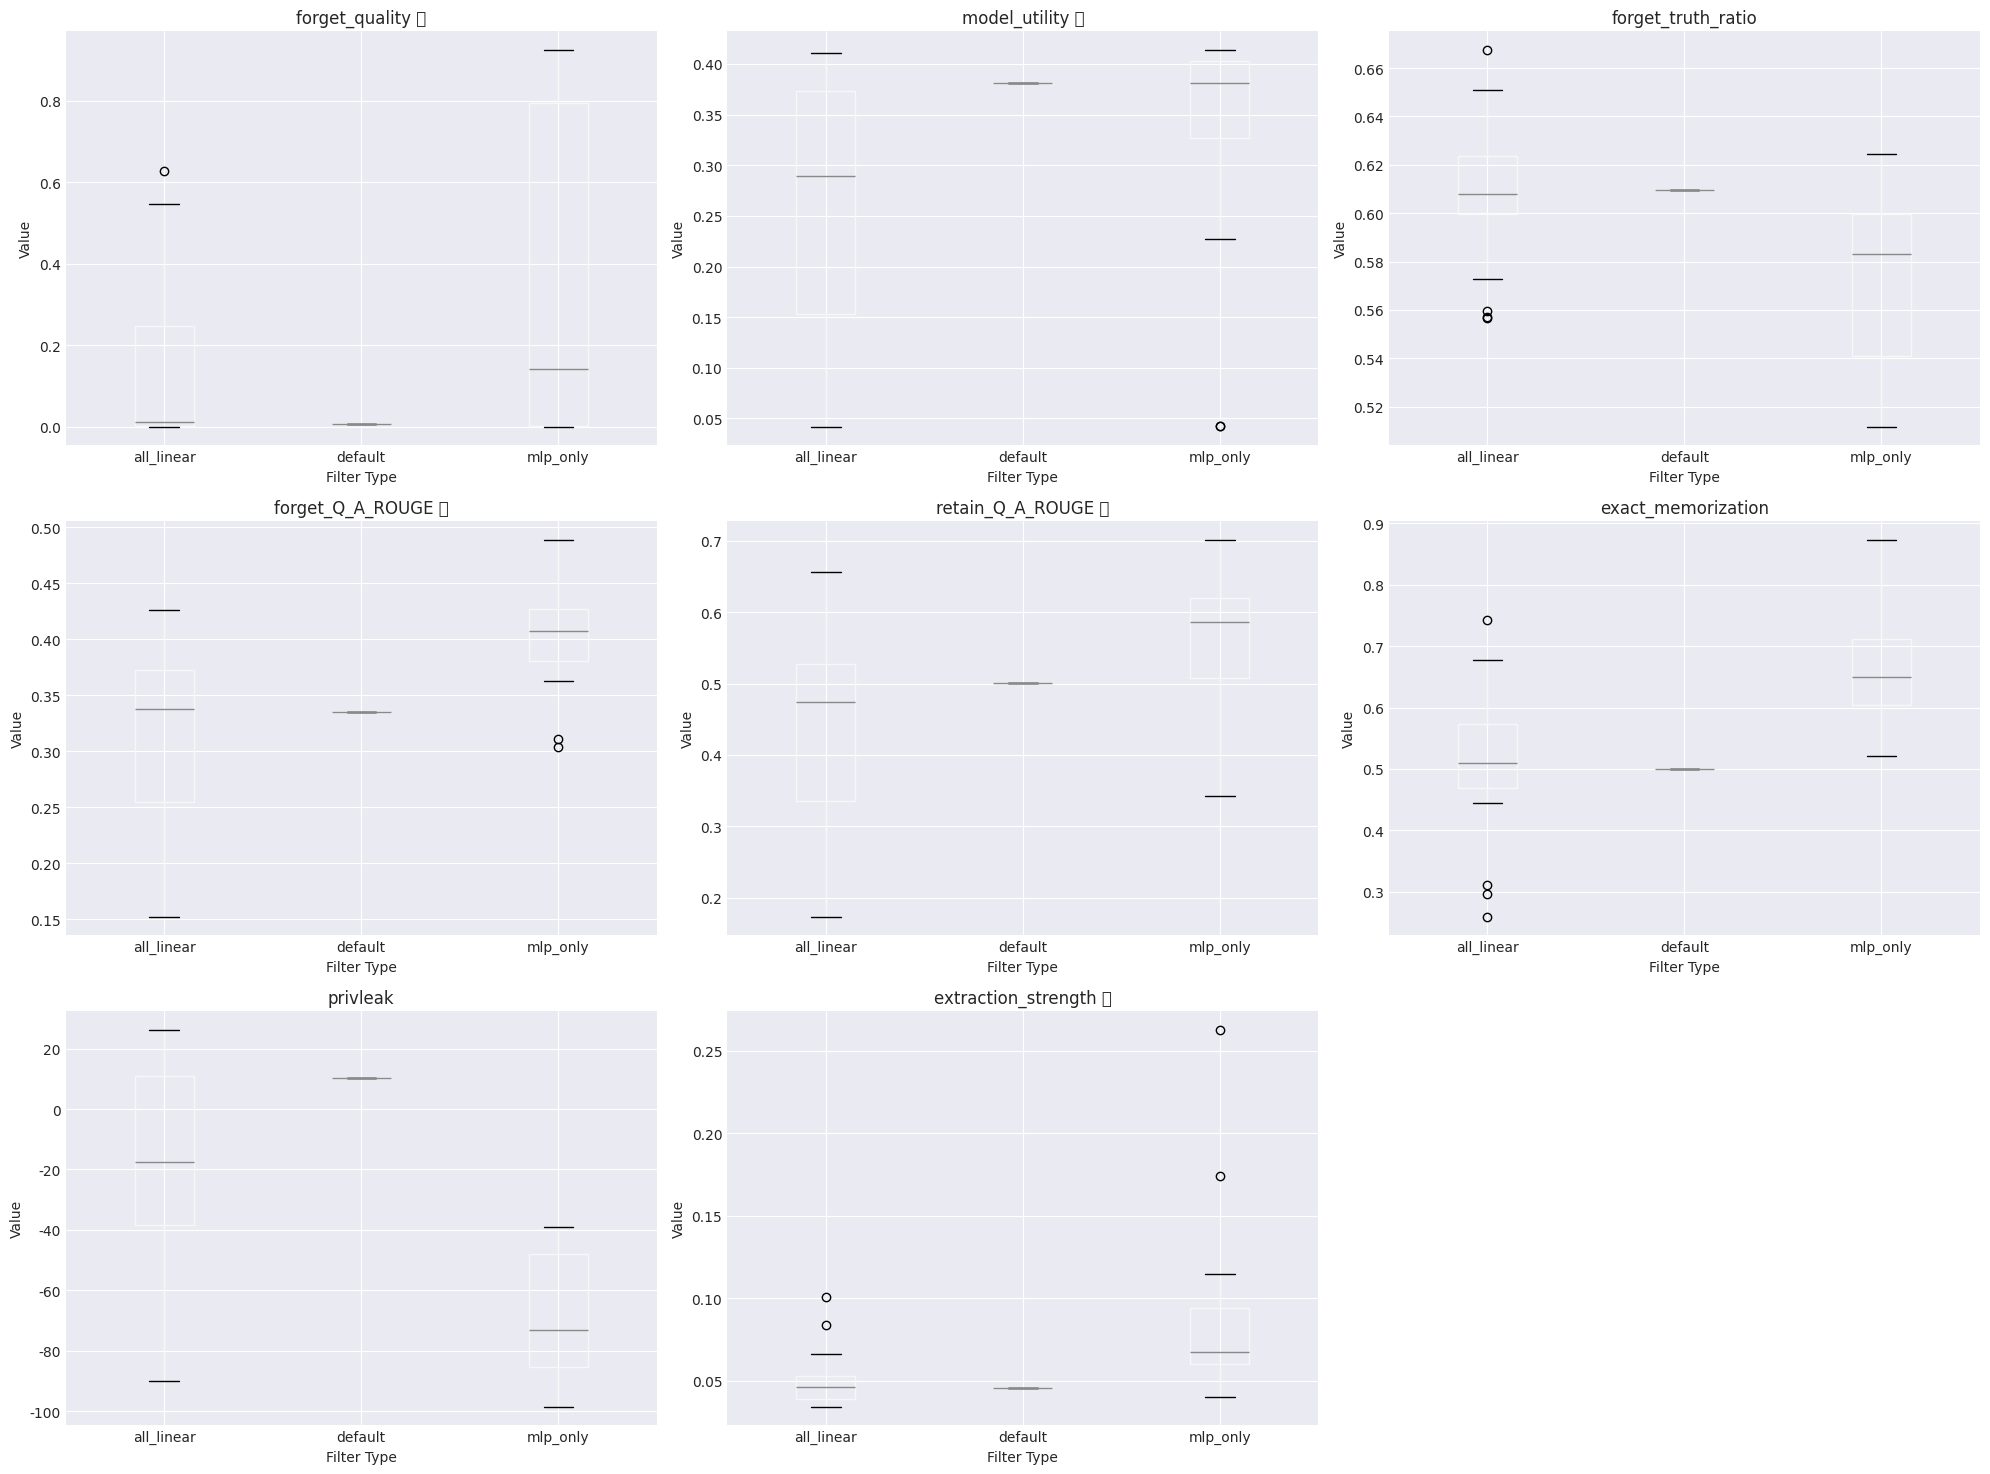


各Filter类型的平均指标:
             forget_quality  model_utility  forget_truth_ratio  \
filter_type                                                      
all_linear           0.1449         0.2542              0.6076   
default              0.0061         0.3813              0.6095   
mlp_only             0.3526         0.3290              0.5730   

             forget_Q_A_ROUGE  retain_Q_A_ROUGE  exact_memorization  privleak  \
filter_type                                                                     
all_linear             0.3107            0.4343              0.5041  -21.5225   
default                0.3354            0.5009              0.4993   10.1479   
mlp_only               0.4021            0.5599              0.6639  -69.0367   

             extraction_strength  
filter_type                       
all_linear                0.0508  
default                   0.0454  
mlp_only                  0.0879  

⭐标记表示参数择优的主要考虑指标（ES, FQ, MU, ROUGE）


In [28]:
# 按filter类型分组对比
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Different Filter Types Performance Comparison (forget05)', fontsize=16, y=0.995)

for idx, metric in enumerate(key_metrics):
    ax = axes[idx // 3, idx % 3]
    
    # 创建箱线图
    df.boxplot(column=metric, by='filter_type', ax=ax)
    
    # 标记主要择优指标
    title_suffix = " ⭐" if metric in ['extraction_strength', 'forget_quality', 'model_utility', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE'] else ""
    ax.set_title(f'{metric}{title_suffix}')
    ax.set_xlabel('Filter Type')
    ax.set_ylabel('Value')
    ax.get_figure().suptitle('')  # 移除默认标题

# 隐藏多余的子图
if len(key_metrics) < 9:
    for idx in range(len(key_metrics), 9):
        axes[idx // 3, idx % 3].axis('off')
    
plt.tight_layout()
plt.show()

# 打印各filter类型的平均值
print("\n各Filter类型的平均指标:")
print("="*80)
filter_comparison = df.groupby('filter_type')[key_metrics].mean()
print(filter_comparison.round(4))

print("\n⭐标记表示参数择优的主要考虑指标（ES, FQ, MU, ROUGE）")

## 4. α和β参数影响分析


Filter类型: all_linear


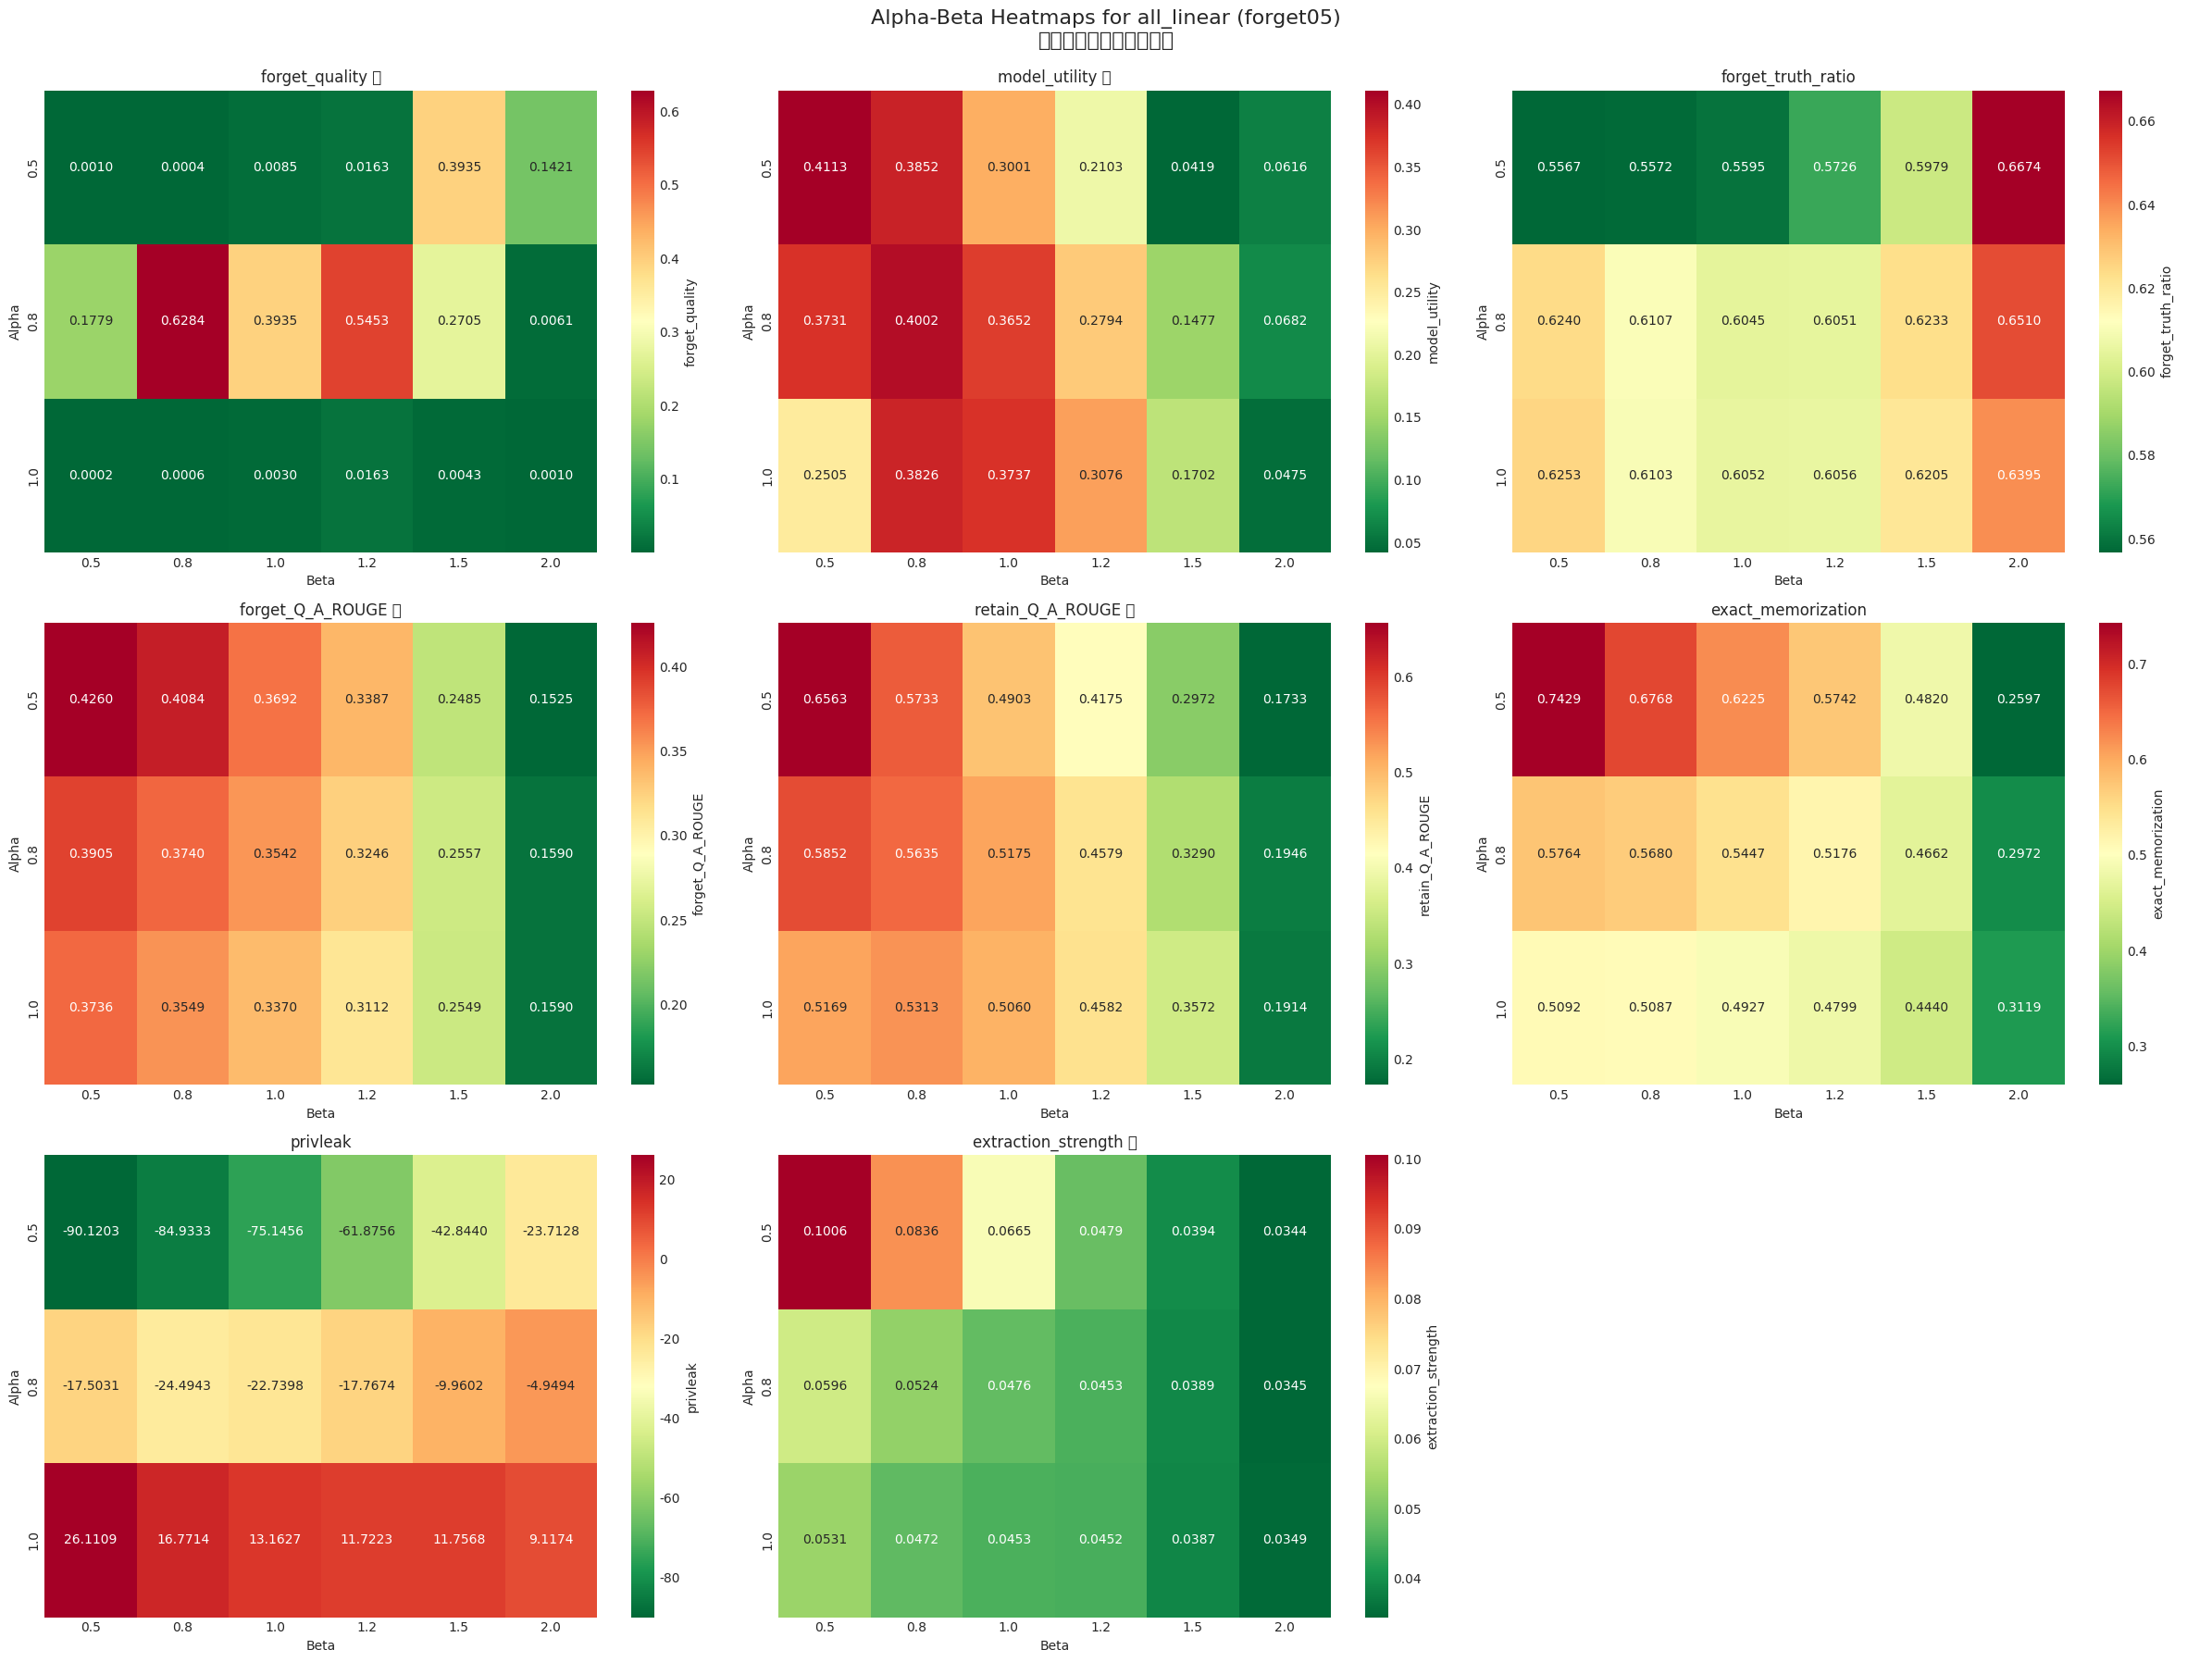


Filter类型: mlp_only


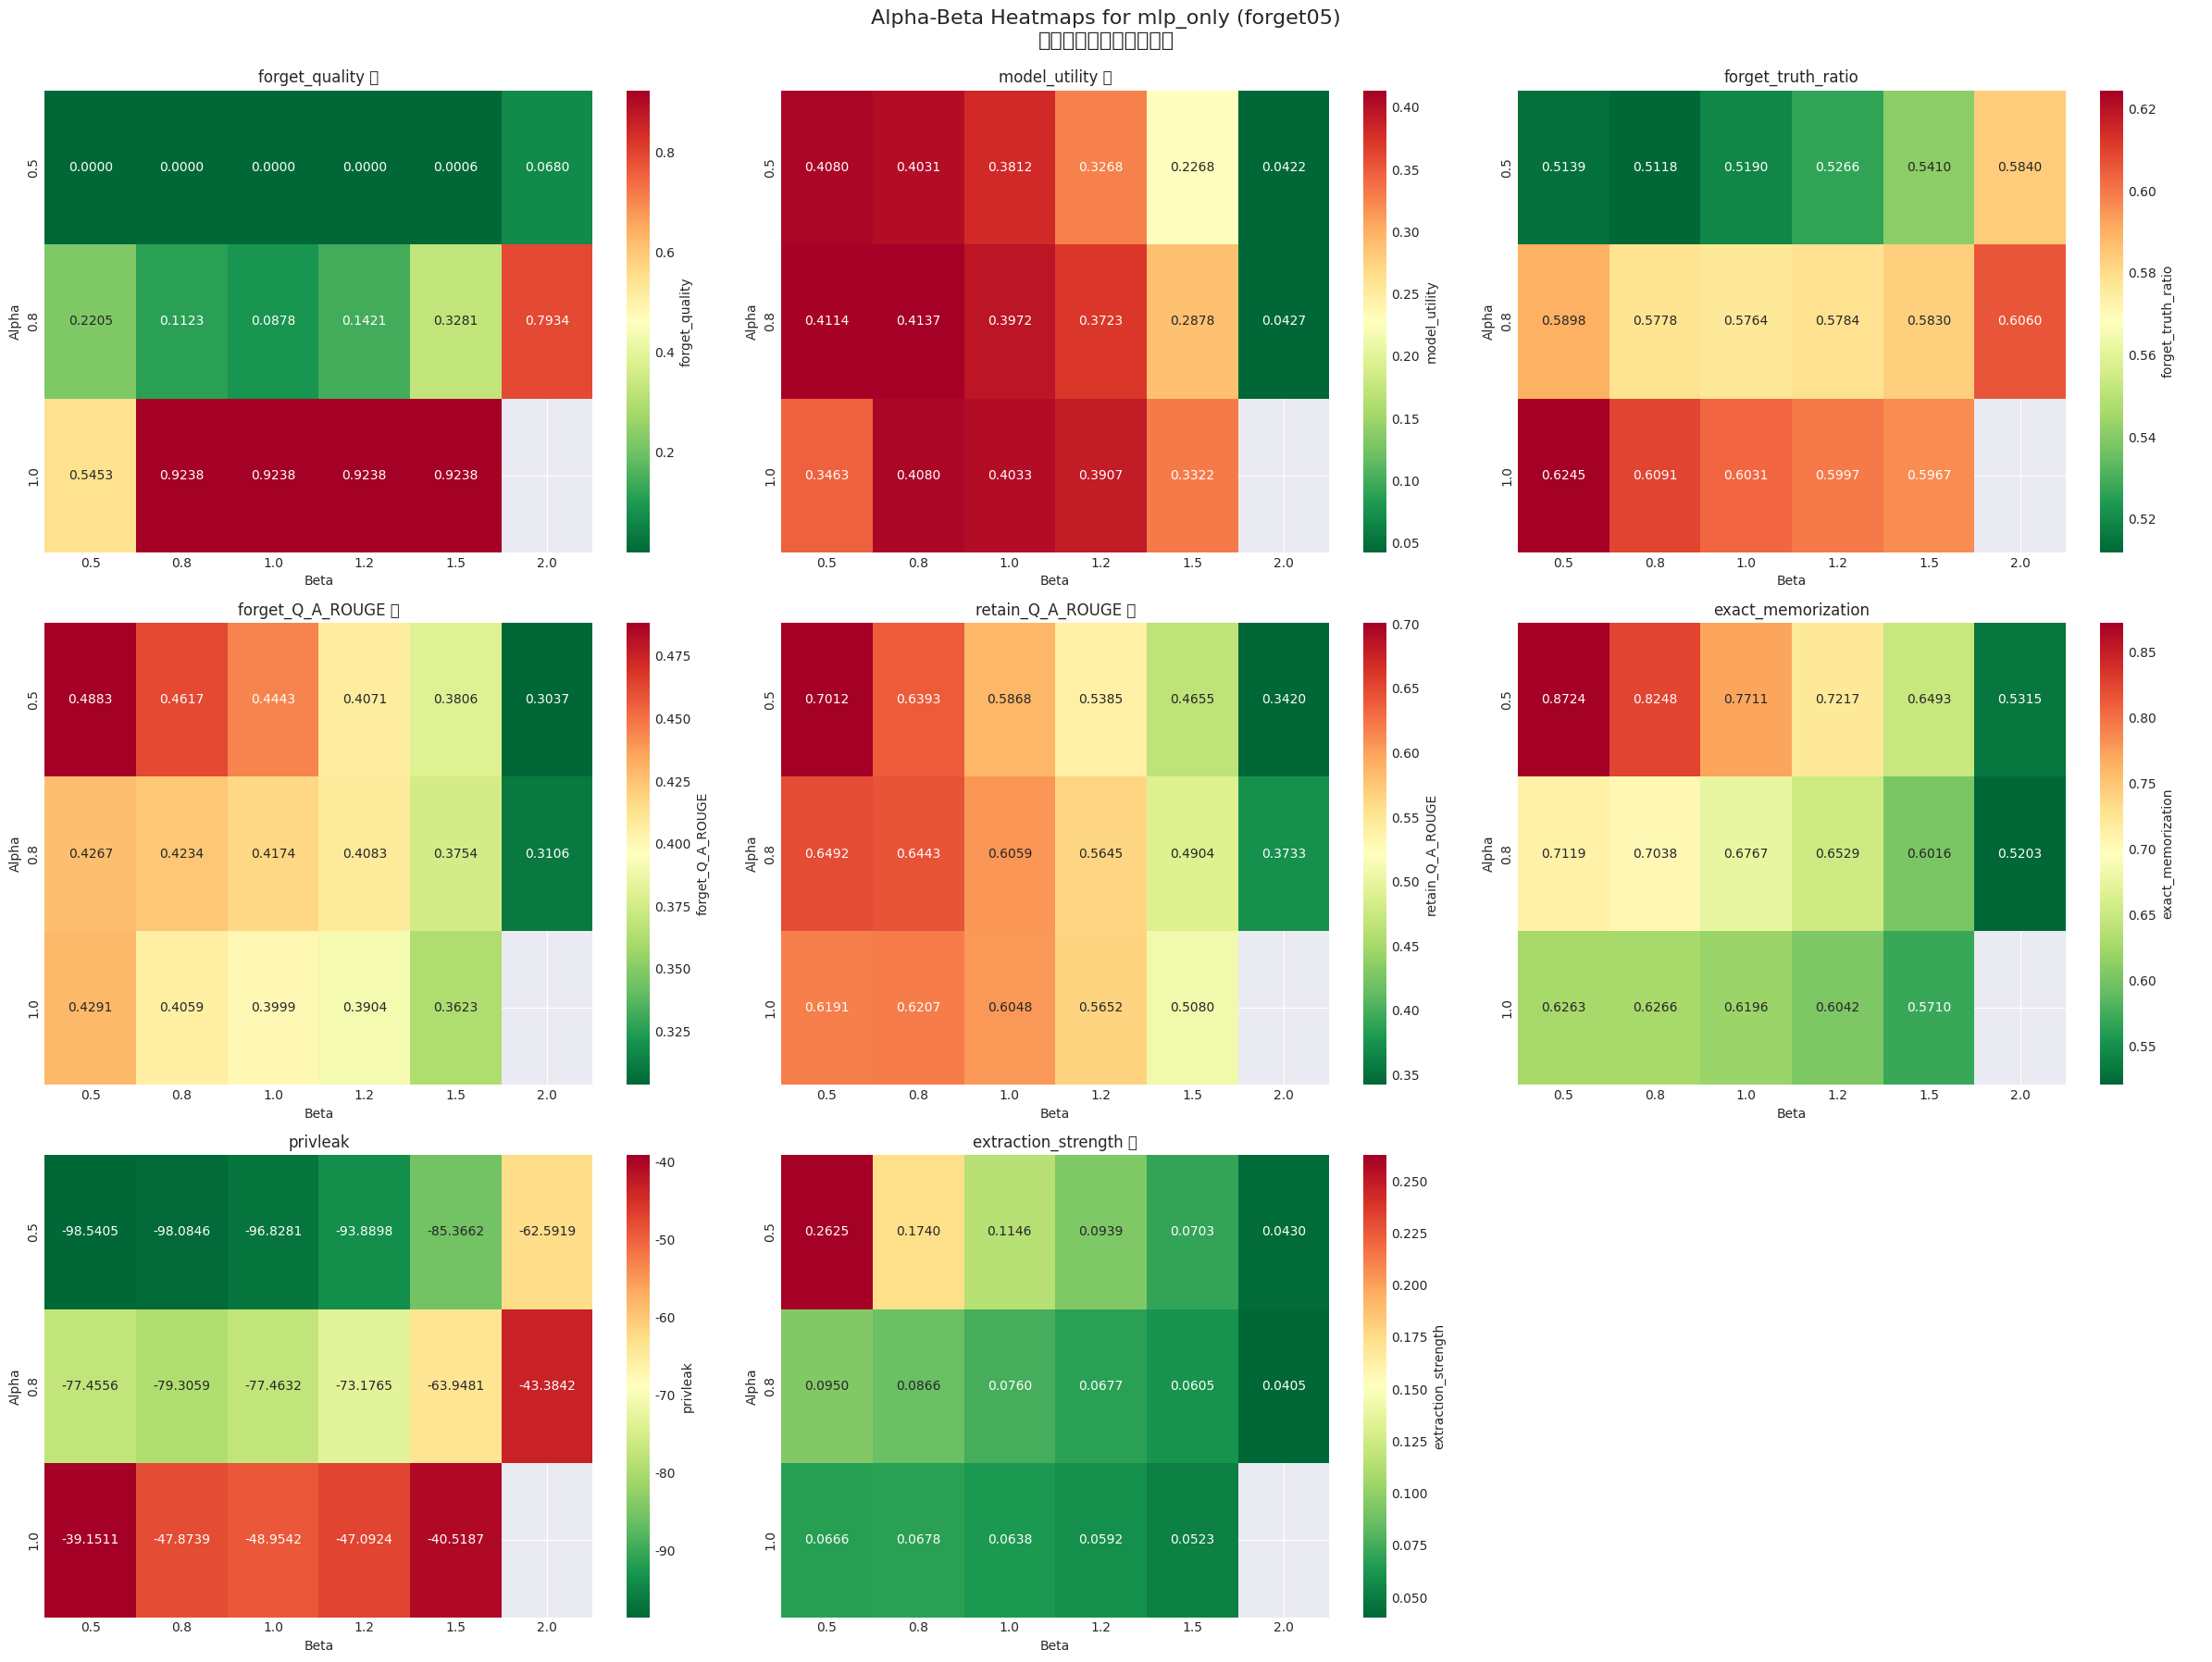

In [29]:
# 为每种filter类型单独分析α和β的影响
filter_types = ['all_linear', 'mlp_only']

for filter_type in filter_types:
    df_filter = df[df['filter_type'] == filter_type].copy()
    
    if len(df_filter) == 0:
        continue
    
    print(f"\n{'='*80}")
    print(f"Filter类型: {filter_type}")
    print(f"{'='*80}")
    
    # 为每个指标创建热力图
    fig, axes = plt.subplots(3, 3, figsize=(24, 18))
    fig.suptitle(f'Alpha-Beta Heatmaps for {filter_type} (forget05)\n⭐标记表示主要择优指标', 
                 fontsize=16, y=0.995)
    
    for idx, metric in enumerate(key_metrics):
        ax = axes[idx // 3, idx % 3]
        
        # 创建pivot table
        pivot_table = df_filter.pivot_table(
            values=metric,
            index='alpha',
            columns='beta',
            aggfunc='mean'
        )
        
        # 绘制热力图
        sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='RdYlGn_r', 
                   ax=ax, cbar_kws={'label': metric})
        
        # 标记主要择优指标
        title_suffix = " ⭐" if metric in ['extraction_strength', 'forget_quality', 'model_utility', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE'] else ""
        ax.set_title(f'{metric}{title_suffix}')
        ax.set_xlabel('Beta')
        ax.set_ylabel('Alpha')
    
    # 隐藏多余的子图
    if len(key_metrics) < 9:
        for idx in range(len(key_metrics), 9):
            axes[idx // 3, idx % 3].axis('off')
    
    plt.tight_layout()
    plt.show()

## 5. α参数的影响（固定β）

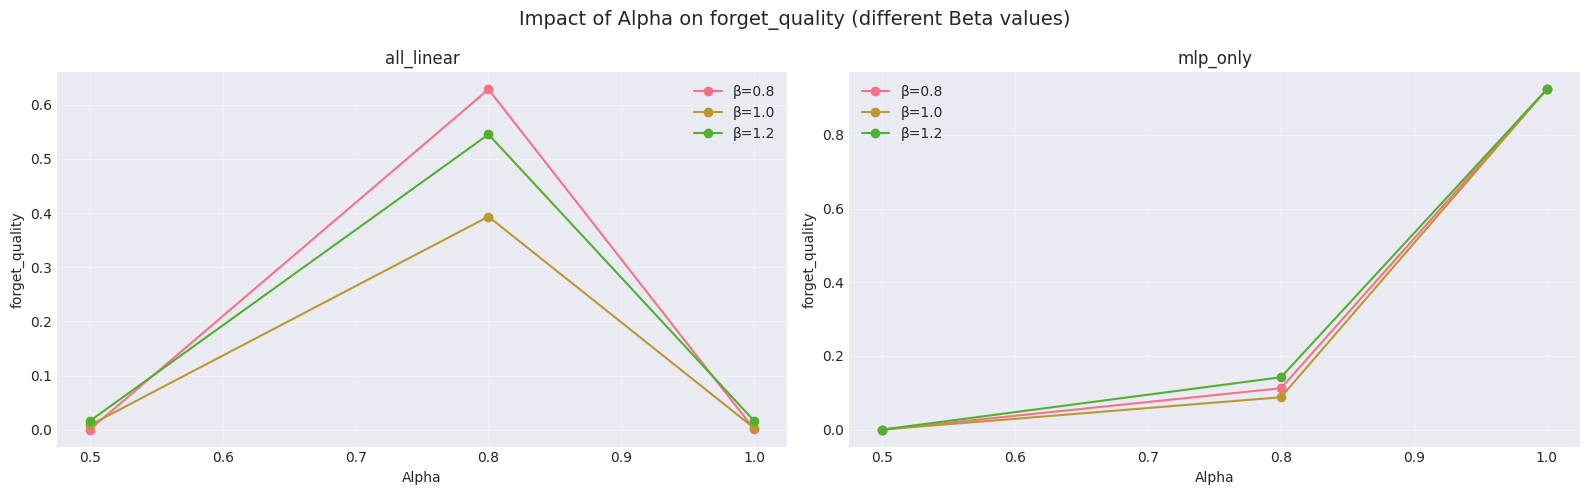

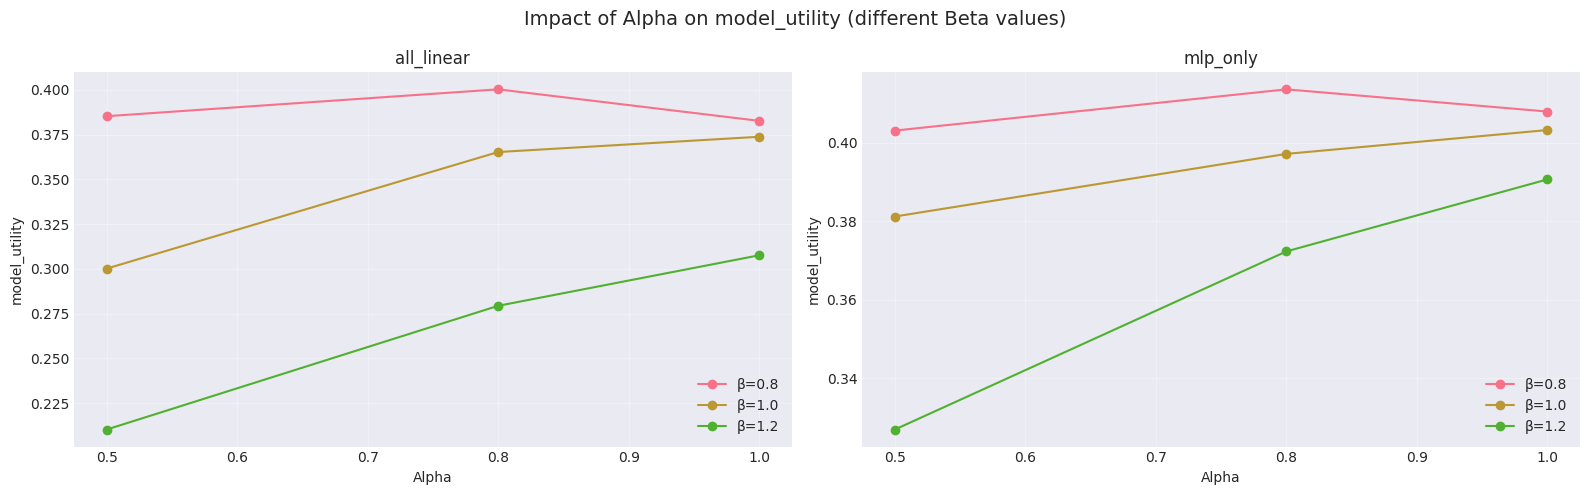

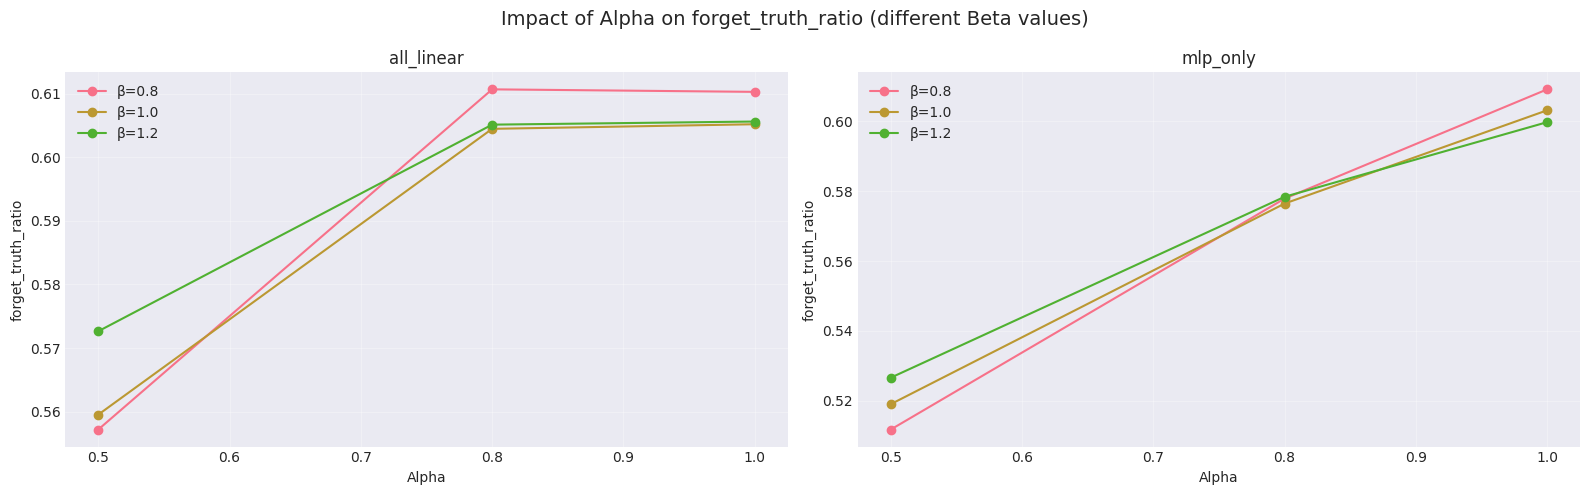

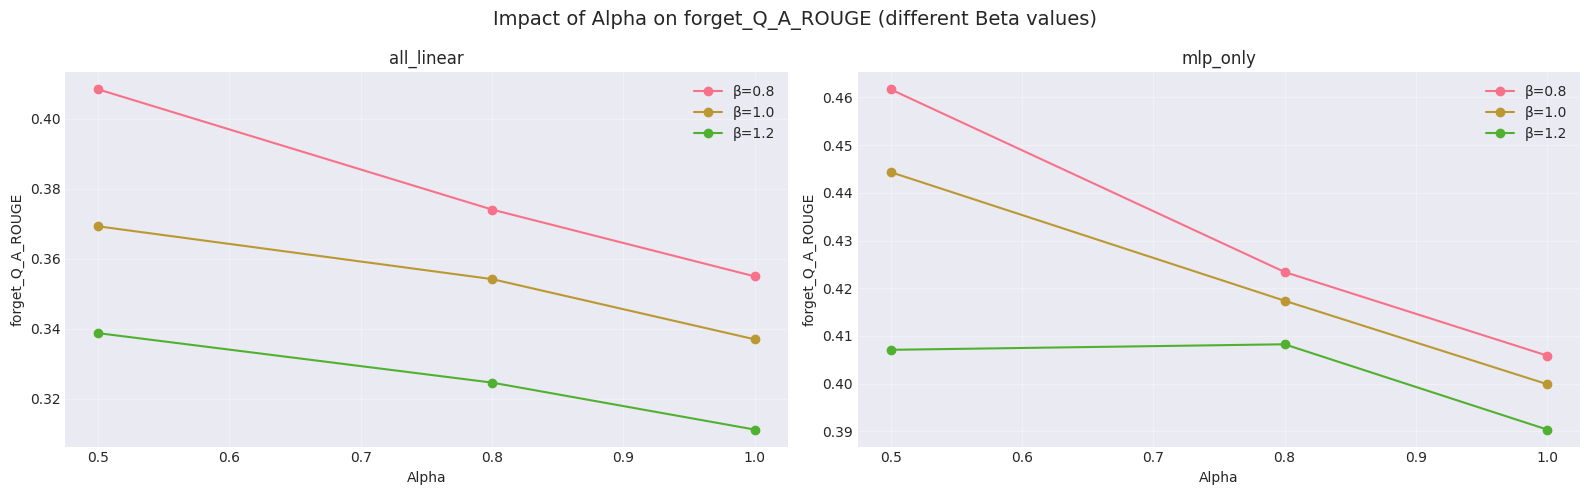

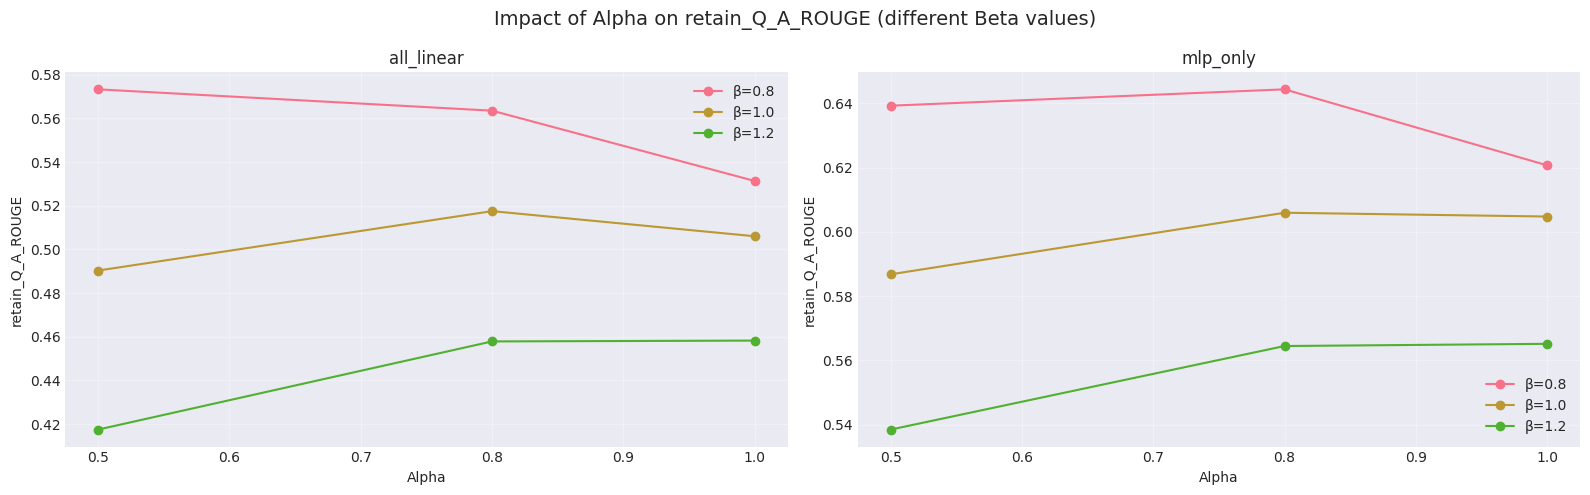

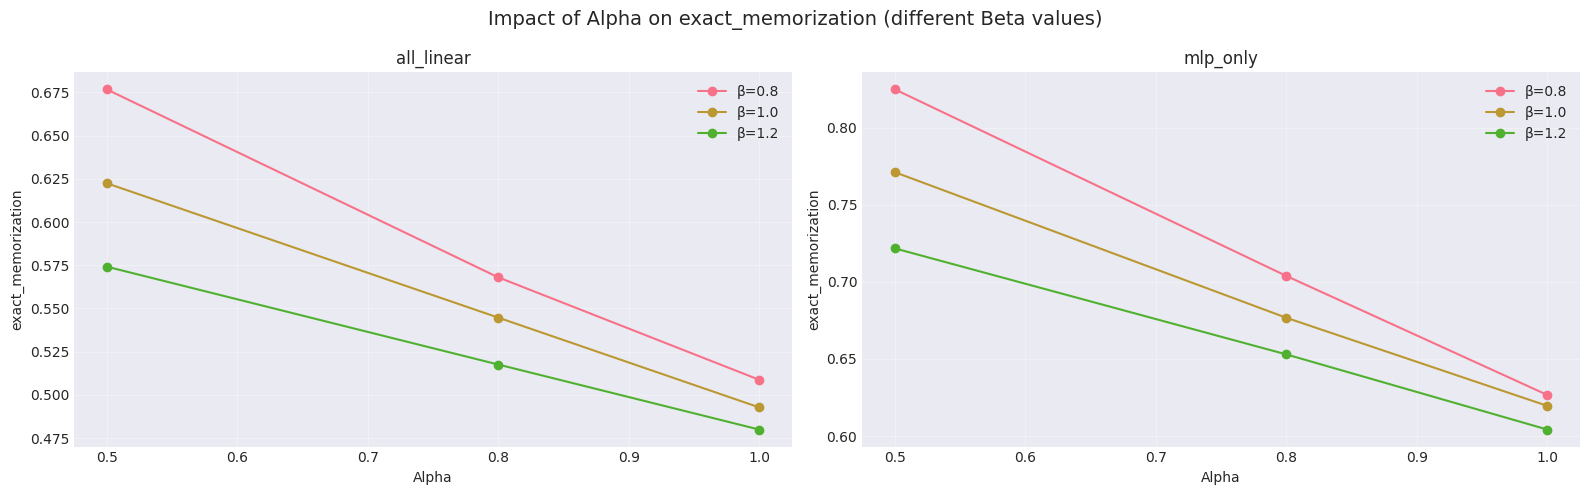

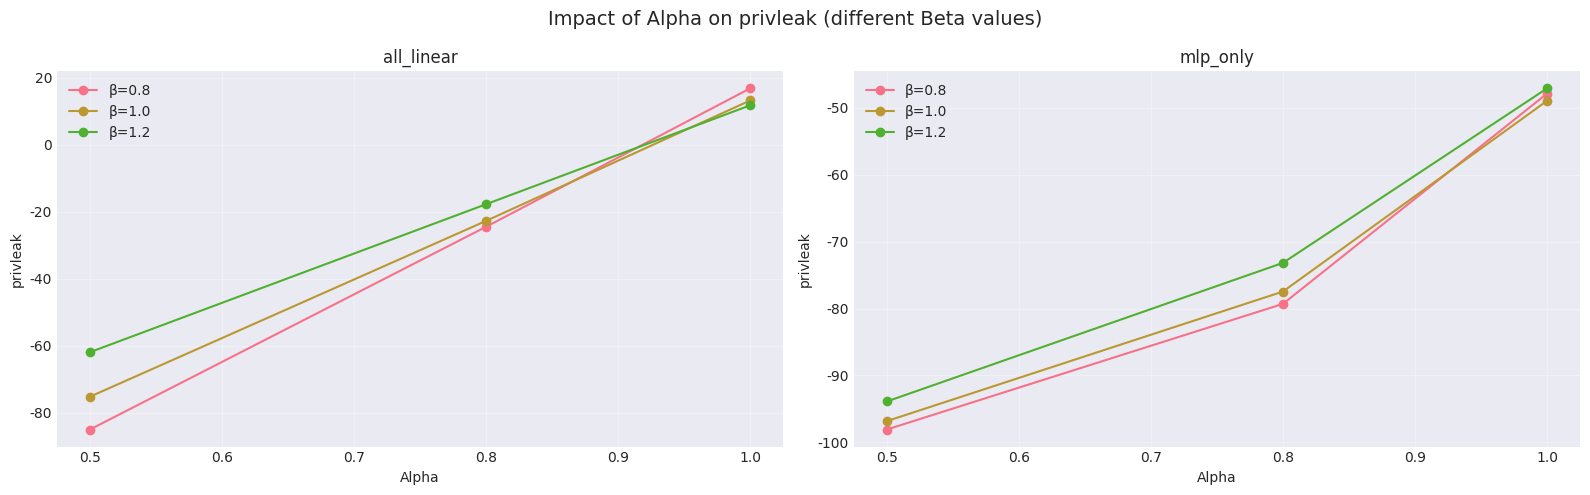

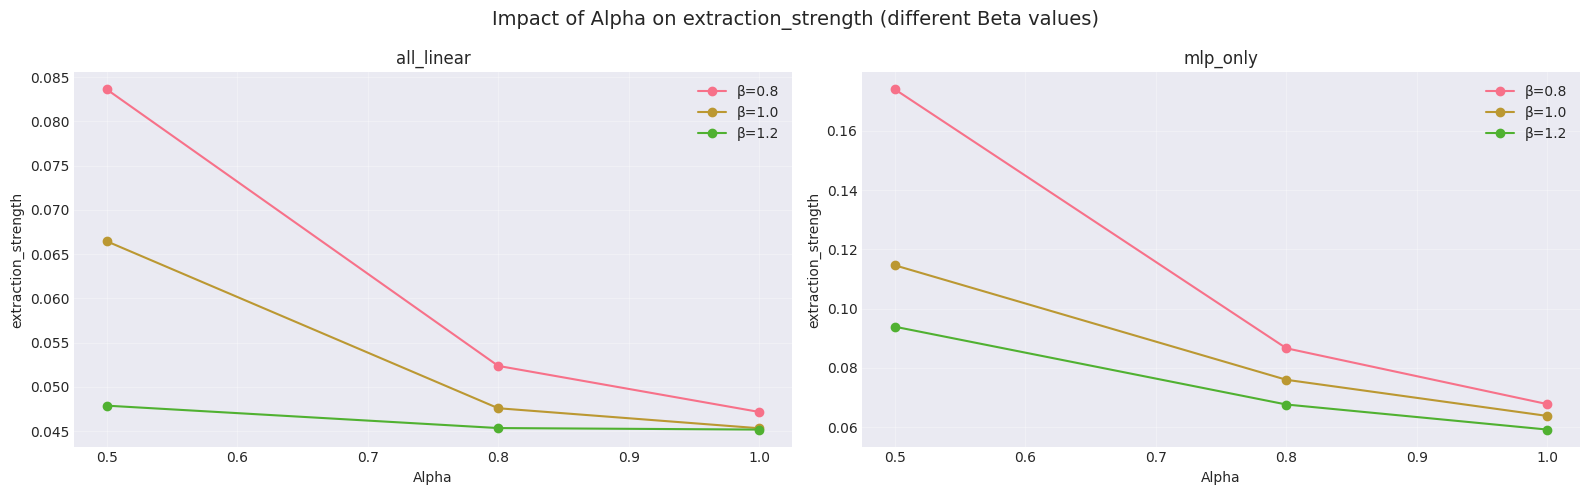

In [30]:
# 选择几个代表性的β值
beta_values = [0.8, 1.0, 1.2]

for metric in key_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Impact of Alpha on {metric} (different Beta values)', fontsize=14)
    
    for idx, filter_type in enumerate(['all_linear', 'mlp_only']):
        ax = axes[idx]
        
        for beta in beta_values:
            df_subset = df[(df['filter_type'] == filter_type) & (df['beta'] == beta)]
            if len(df_subset) > 0:
                df_subset_sorted = df_subset.sort_values('alpha')
                ax.plot(df_subset_sorted['alpha'], df_subset_sorted[metric], 
                       marker='o', label=f'β={beta}')
        
        ax.set_xlabel('Alpha')
        ax.set_ylabel(metric)
        ax.set_title(f'{filter_type}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 6. β参数的影响（固定α）

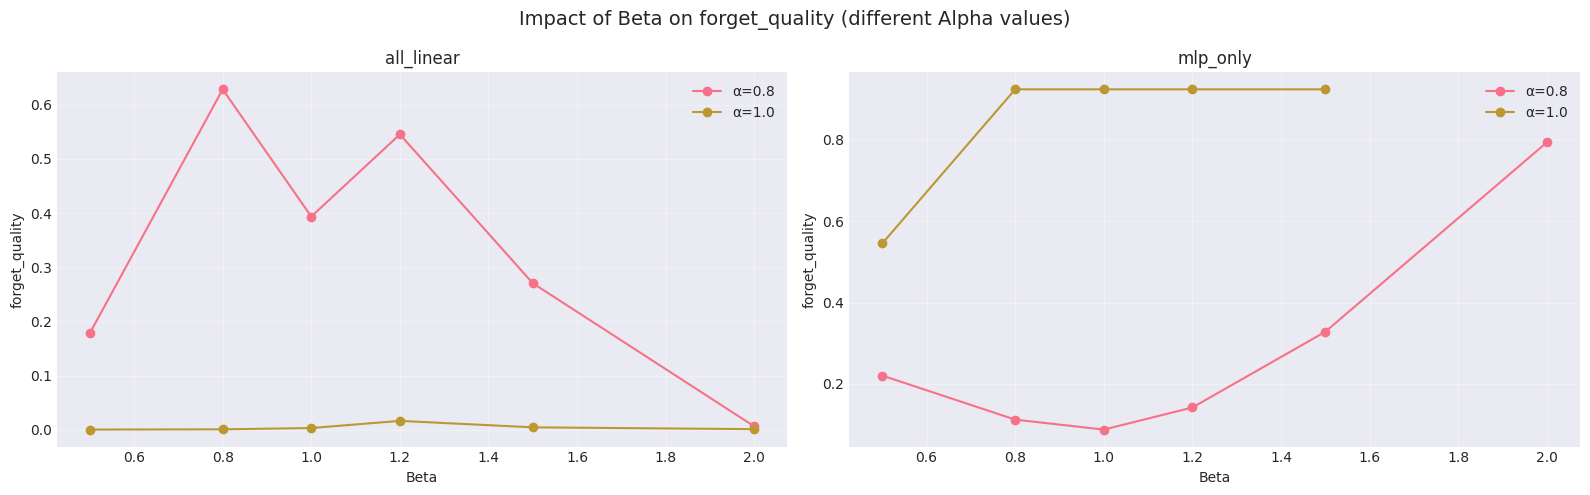

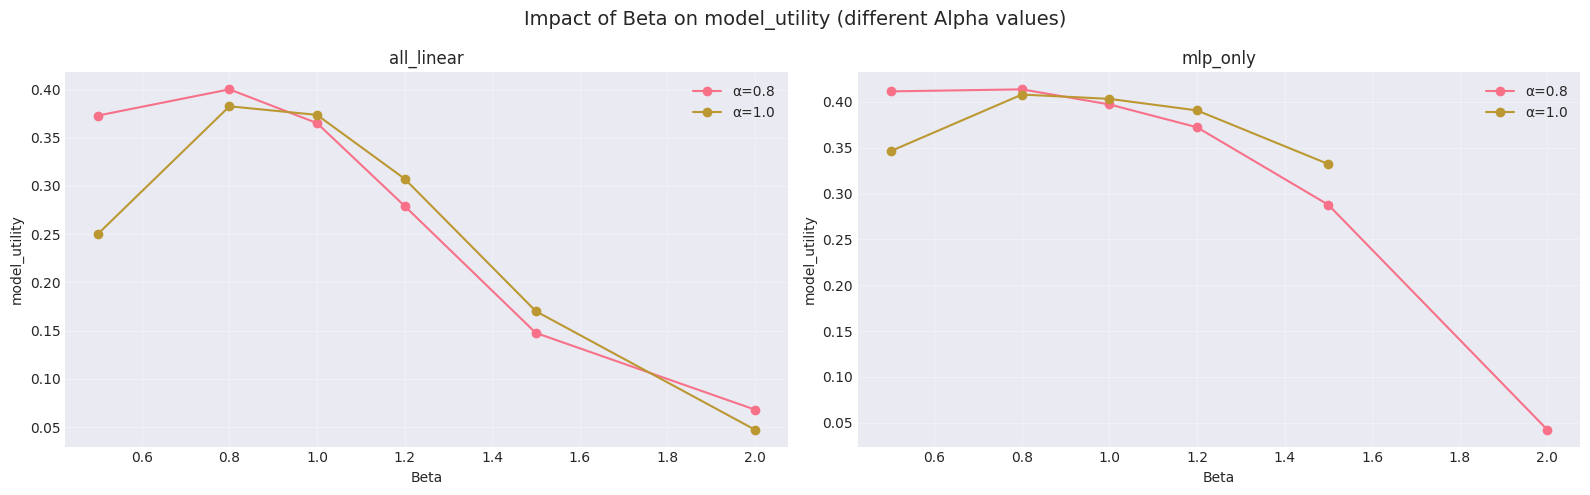

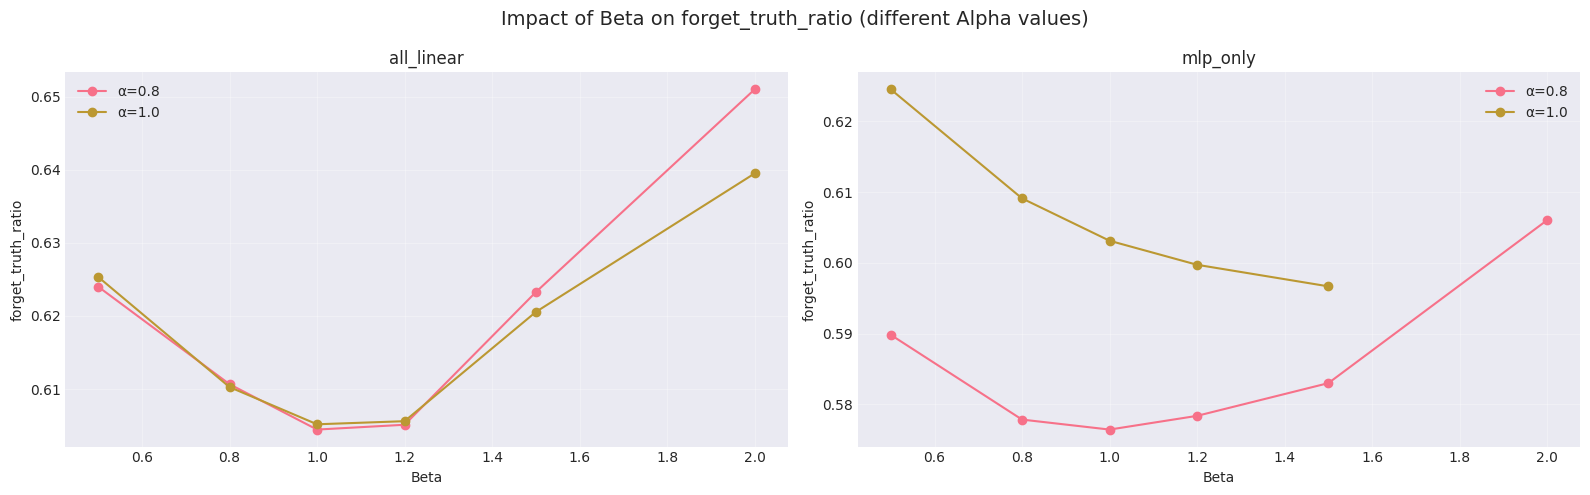

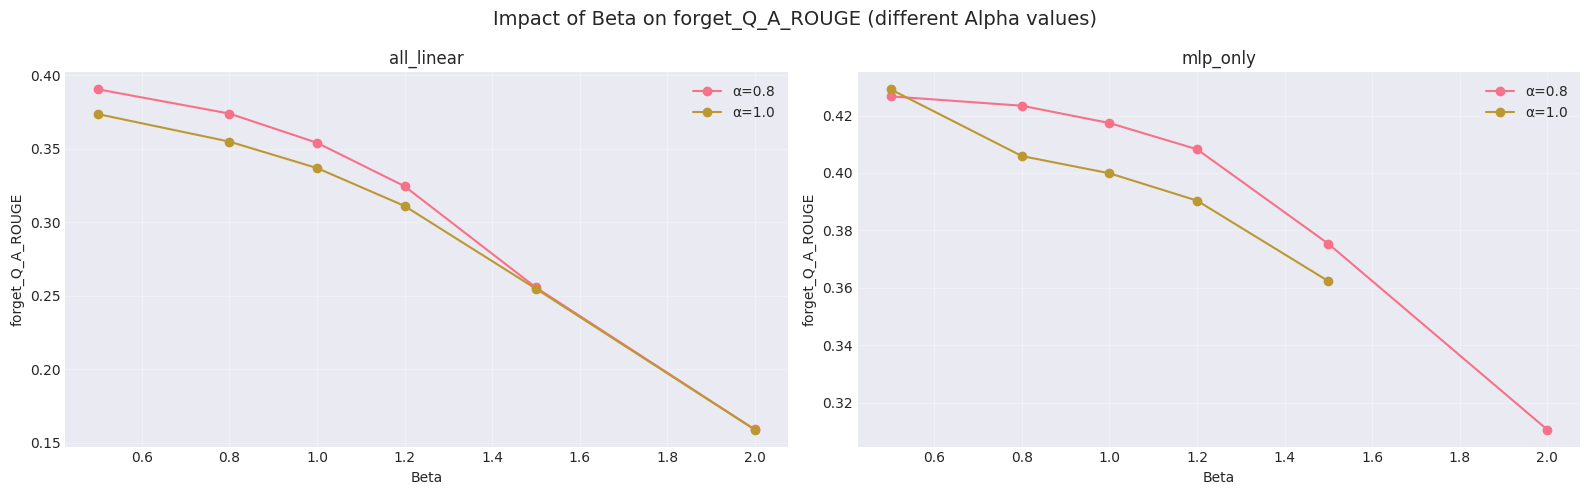

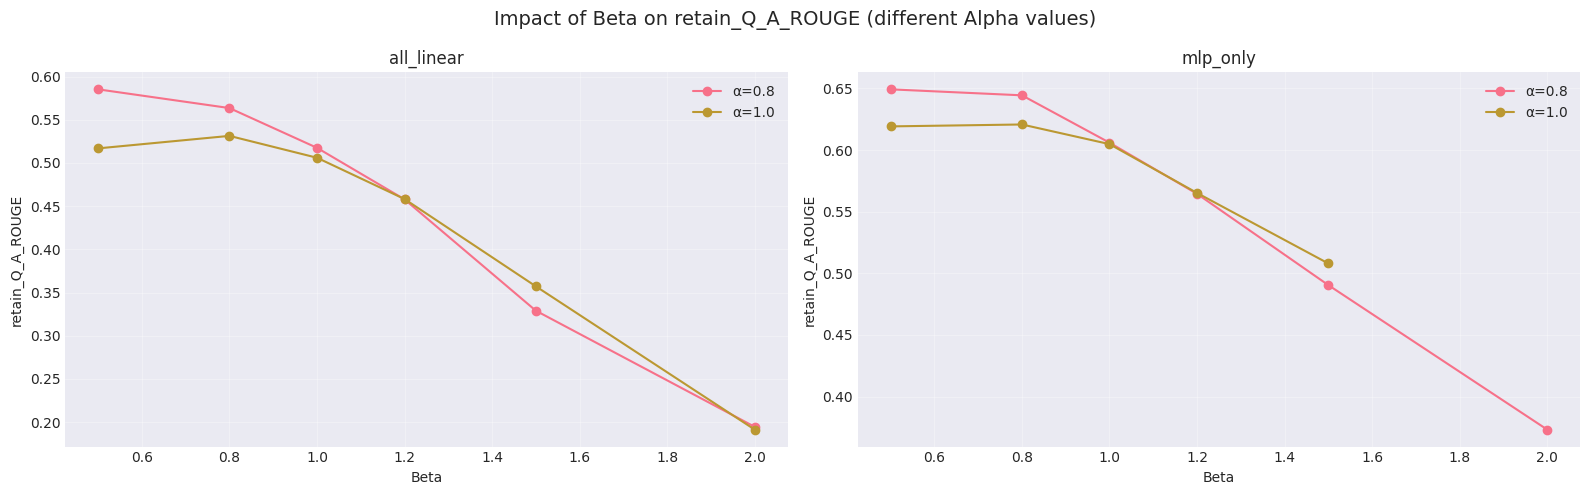

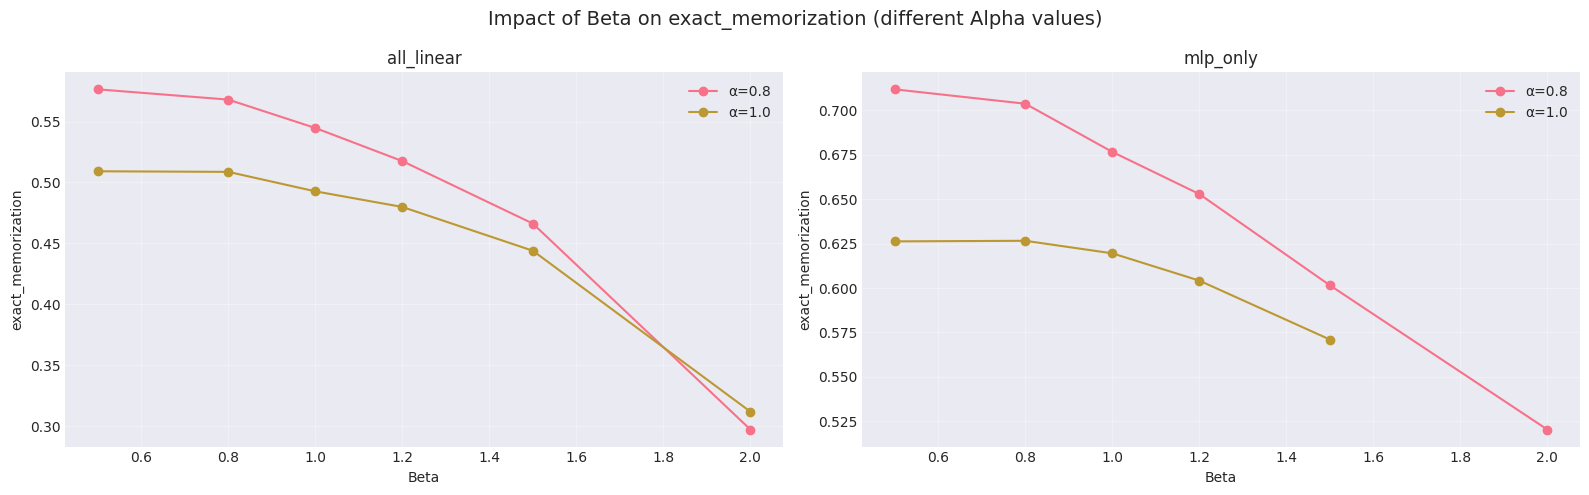

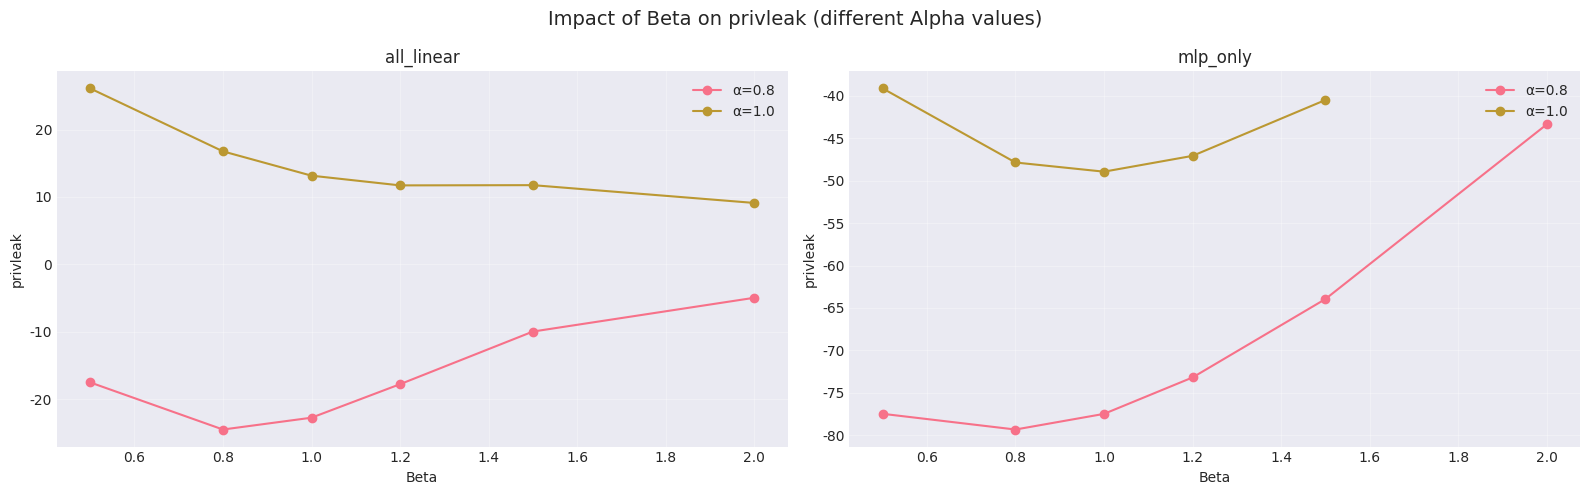

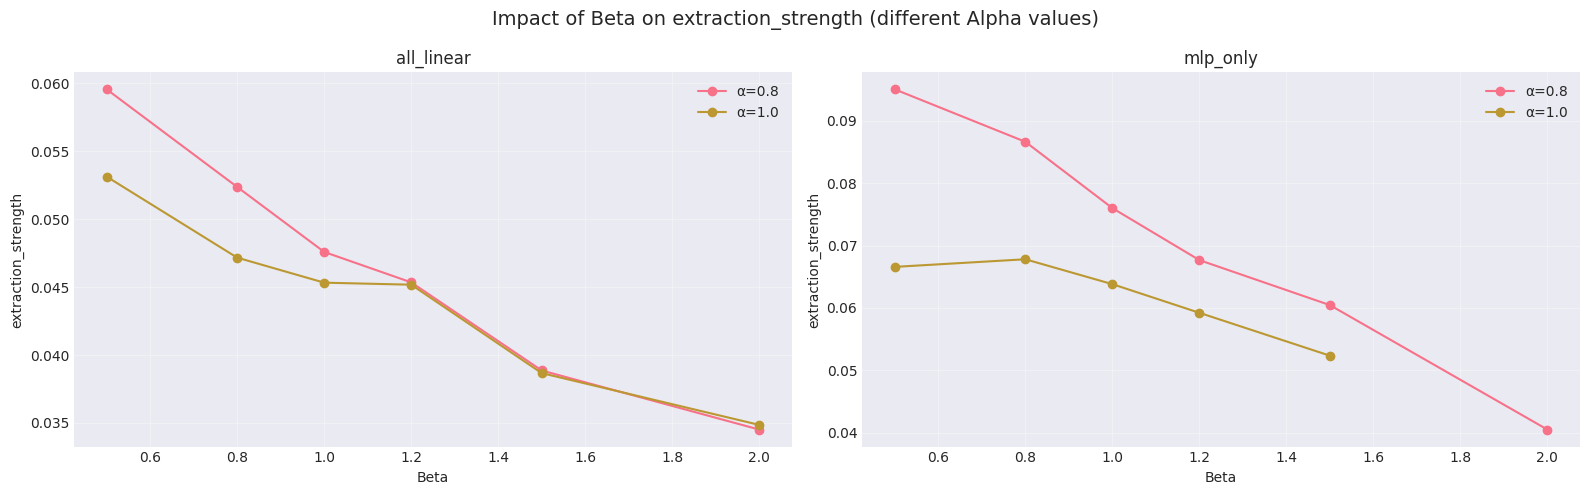

In [31]:
# 选择几个代表性的α值
alpha_values = [0.8, 1.0, 1.2]

for metric in key_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f'Impact of Beta on {metric} (different Alpha values)', fontsize=14)
    
    for idx, filter_type in enumerate(['all_linear', 'mlp_only']):
        ax = axes[idx]
        
        for alpha in alpha_values:
            df_subset = df[(df['filter_type'] == filter_type) & (df['alpha'] == alpha)]
            if len(df_subset) > 0:
                df_subset_sorted = df_subset.sort_values('beta')
                ax.plot(df_subset_sorted['beta'], df_subset_sorted[metric], 
                       marker='o', label=f'α={alpha}')
        
        ax.set_xlabel('Beta')
        ax.set_ylabel(metric)
        ax.set_title(f'{filter_type}')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 7. 最佳配置识别

## 6.5. 主要择优指标深入分析

重点关注4个核心指标：
- **ES (extraction_strength)**: 越低越好
- **FQ (forget_quality)**: 越高越好
- **MU (model_utility)**: 越高越好  
- **ROUGE**: forget_Q_A_ROUGE越低越好，retain_Q_A_ROUGE越高越好

KeyError: 'composite_score'

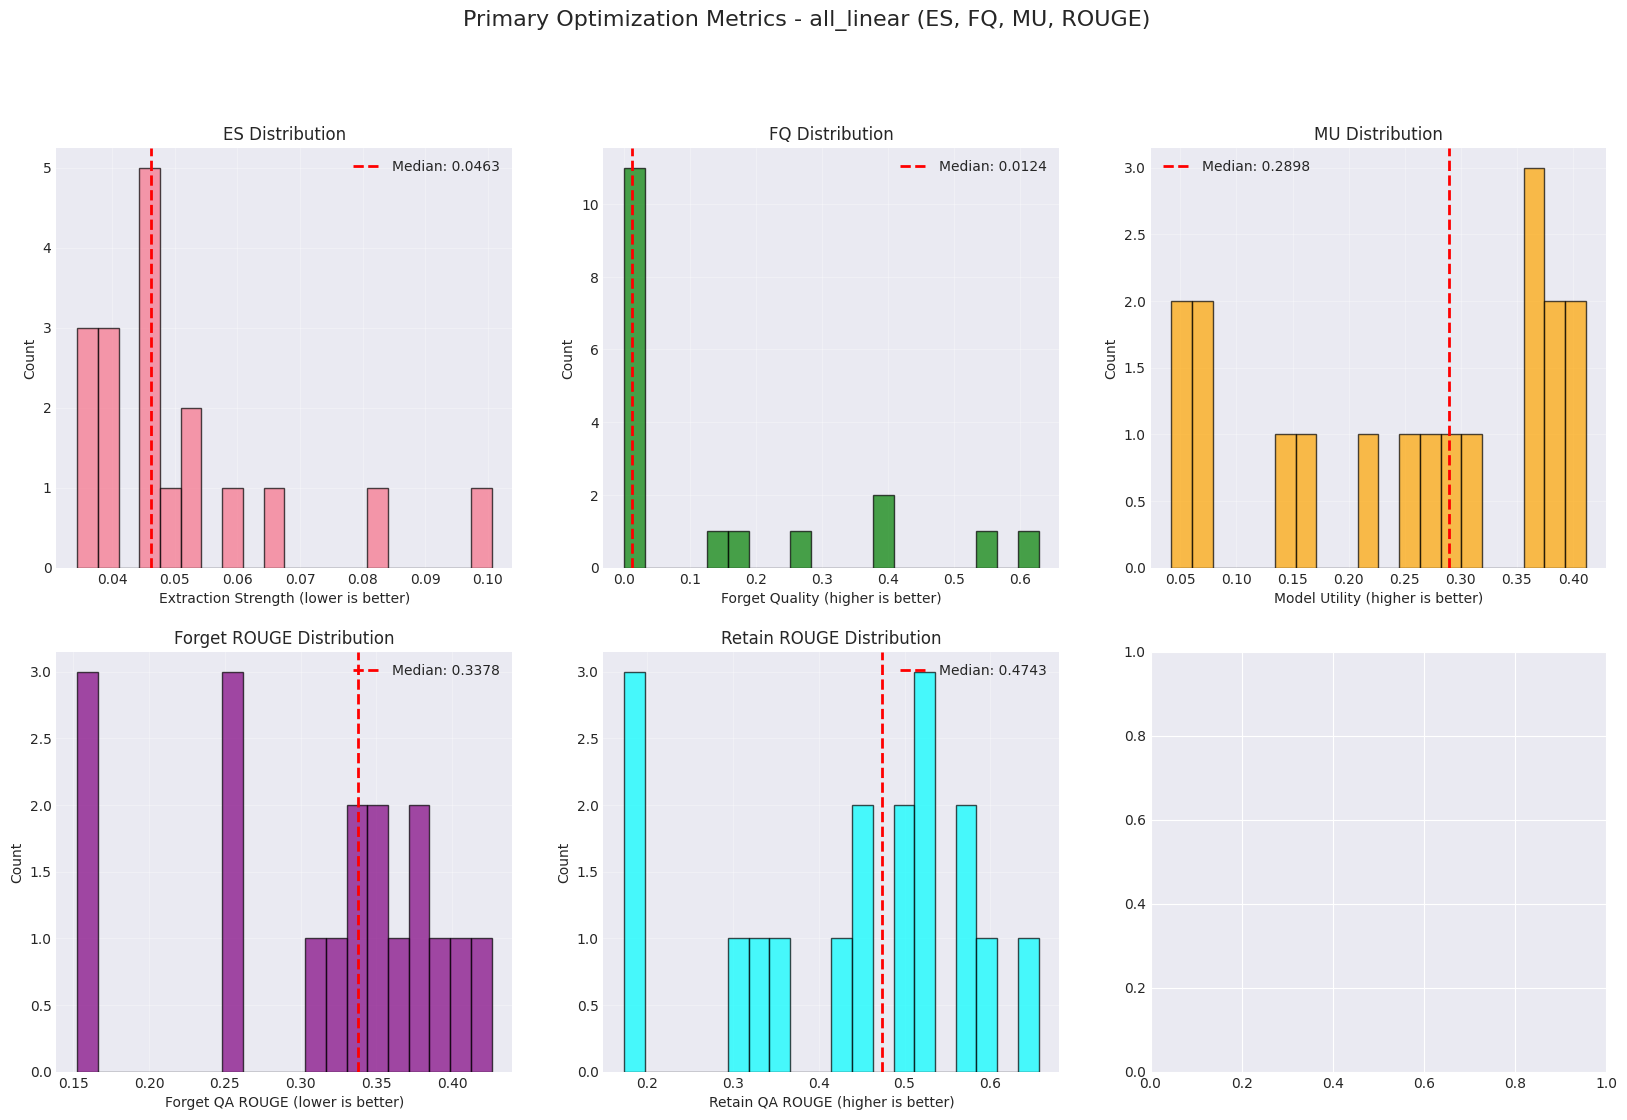

In [32]:
# 主要择优指标分析
primary_metrics = ['extraction_strength', 'forget_quality', 'model_utility', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE']

# 为每种filter类型创建主要指标的对比图
for filter_type in ['all_linear', 'mlp_only']:
    df_filter = df[df['filter_type'] == filter_type].copy()
    
    if len(df_filter) == 0:
        continue
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Primary Optimization Metrics - {filter_type} (ES, FQ, MU, ROUGE)', 
                 fontsize=16, y=0.995)
    
    # 1. 提取强度分布
    ax = axes[0, 0]
    ax.hist(df_filter['extraction_strength'], bins=20, alpha=0.7, edgecolor='black')
    ax.axvline(df_filter['extraction_strength'].median(), color='red', linestyle='--', 
               linewidth=2, label=f'Median: {df_filter["extraction_strength"].median():.4f}')
    ax.set_xlabel('Extraction Strength (lower is better)')
    ax.set_ylabel('Count')
    ax.set_title('ES Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. 遗忘质量分布
    ax = axes[0, 1]
    ax.hist(df_filter['forget_quality'], bins=20, alpha=0.7, edgecolor='black', color='green')
    ax.axvline(df_filter['forget_quality'].median(), color='red', linestyle='--', 
               linewidth=2, label=f'Median: {df_filter["forget_quality"].median():.4f}')
    ax.set_xlabel('Forget Quality (higher is better)')
    ax.set_ylabel('Count')
    ax.set_title('FQ Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. 模型效用分布
    ax = axes[0, 2]
    ax.hist(df_filter['model_utility'], bins=20, alpha=0.7, edgecolor='black', color='orange')
    ax.axvline(df_filter['model_utility'].median(), color='red', linestyle='--', 
               linewidth=2, label=f'Median: {df_filter["model_utility"].median():.4f}')
    ax.set_xlabel('Model Utility (higher is better)')
    ax.set_ylabel('Count')
    ax.set_title('MU Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Forget ROUGE分布
    ax = axes[1, 0]
    ax.hist(df_filter['forget_Q_A_ROUGE'], bins=20, alpha=0.7, edgecolor='black', color='purple')
    ax.axvline(df_filter['forget_Q_A_ROUGE'].median(), color='red', linestyle='--', 
               linewidth=2, label=f'Median: {df_filter["forget_Q_A_ROUGE"].median():.4f}')
    ax.set_xlabel('Forget QA ROUGE (lower is better)')
    ax.set_ylabel('Count')
    ax.set_title('Forget ROUGE Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 5. Retain ROUGE分布
    ax = axes[1, 1]
    ax.hist(df_filter['retain_Q_A_ROUGE'], bins=20, alpha=0.7, edgecolor='black', color='cyan')
    ax.axvline(df_filter['retain_Q_A_ROUGE'].median(), color='red', linestyle='--', 
               linewidth=2, label=f'Median: {df_filter["retain_Q_A_ROUGE"].median():.4f}')
    ax.set_xlabel('Retain QA ROUGE (higher is better)')
    ax.set_ylabel('Count')
    ax.set_title('Retain ROUGE Distribution')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 6. 综合得分与主要指标的关系
    ax = axes[1, 2]
    # 归一化主要指标并计算平均得分
    df_filter_norm = df_filter.copy()
    for metric in primary_metrics:
        if metric in ['extraction_strength', 'forget_Q_A_ROUGE']:
            # 越小越好的指标
            df_filter_norm[f'{metric}_norm'] = 1 - (df_filter[metric] - df_filter[metric].min()) / (df_filter[metric].max() - df_filter[metric].min() + 1e-10)
        else:
            # 越大越好的指标
            df_filter_norm[f'{metric}_norm'] = (df_filter[metric] - df_filter[metric].min()) / (df_filter[metric].max() - df_filter[metric].min() + 1e-10)
    
    primary_score = df_filter_norm[[f'{m}_norm' for m in primary_metrics]].mean(axis=1)
    ax.scatter(primary_score, df_filter['composite_score'], alpha=0.6, s=100)
    ax.set_xlabel('Primary Metrics Average Score')
    ax.set_ylabel('Composite Score')
    ax.set_title('Primary Metrics vs Composite Score')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 打印最佳配置（基于主要指标）
    print(f"\n{filter_type} - 基于主要指标的Top 3配置:")
    print("="*100)
    top3 = df_filter.nlargest(3, 'composite_score')
    print(top3[['alpha', 'beta'] + primary_metrics].to_string(index=False))

In [ ]:
# 定义综合得分计算函数
def calculate_composite_score(row):
    """计算综合得分（归一化后加权）
    
    参数择优主要考虑4个指标：
    - extraction_strength (ES)
    - forget_quality (FQ) 
    - model_utility (MU)
    - ROUGE (包括forget_Q_A_ROUGE和retain_Q_A_ROUGE)
    """
    # 需要最小化的指标（越小越好）
    minimize_metrics = ['forget_Q_A_ROUGE', 'exact_memorization', 'privleak', 'extraction_strength']
    # 需要最大化的指标（越大越好）
    maximize_metrics = ['forget_quality', 'model_utility', 'forget_truth_ratio', 'retain_Q_A_ROUGE']
    
    # 主要指标权重（ES, FQ, MU, ROUGE）
    primary_metrics = {
        'extraction_strength': 2.0,
        'forget_quality': 2.0,
        'model_utility': 2.0,
        'forget_Q_A_ROUGE': 1.5,
        'retain_Q_A_ROUGE': 1.5
    }
    
    score = 0
    
    # 归一化并计算得分
    for metric in minimize_metrics:
        if metric in row and metric in df.columns:
            min_val = df[metric].min()
            max_val = df[metric].max()
            if max_val > min_val:
                normalized = 1 - (row[metric] - min_val) / (max_val - min_val)
                weight = primary_metrics.get(metric, 1.0)
                score += normalized * weight
    
    for metric in maximize_metrics:
        if metric in row and metric in df.columns:
            min_val = df[metric].min()
            max_val = df[metric].max()
            if max_val > min_val:
                normalized = (row[metric] - min_val) / (max_val - min_val)
                weight = primary_metrics.get(metric, 1.0)
                score += normalized * weight
    
    return score

# 计算综合得分
df['composite_score'] = df.apply(calculate_composite_score, axis=1)

# 为每种filter类型找出最佳配置
print("\n最佳配置 Top 5 (基于ES、FQ、MU、ROUGE择优):")
print("="*100)

for filter_type in df['filter_type'].unique():
    print(f"\nFilter类型: {filter_type}")
    print("-"*100)
    
    df_filter = df[df['filter_type'] == filter_type].copy()
    top_configs = df_filter.nlargest(5, 'composite_score')
    
    display_cols = ['alpha', 'beta', 'composite_score'] + key_metrics
    print(top_configs[display_cols].to_string(index=False))
    print()


最佳配置 Top 5:

Filter类型: all_linear
----------------------------------------------------------------------------------------------------
 alpha  beta  composite_score  forget_quality  model_utility  forget_truth_ratio  retain_Q_A_Prob  exact_memorization   privleak
   0.5   0.5         4.810769        0.000967       0.411332            0.556708         0.877585            0.742888 -90.120288
   0.5   0.8         4.662655        0.000431       0.385215            0.557185         0.754380            0.676817 -84.933344
   0.5   1.0         4.271444        0.008539       0.300132            0.559529         0.625020            0.622477 -75.145572
   0.5   1.2         3.749342        0.016258       0.210285            0.572636         0.485644            0.574199 -61.875575
   1.0   0.8         3.725426        0.000649       0.382629            0.610266         0.713120            0.508709  16.771376


Filter类型: mlp_only
---------------------------------------------------------------------

## 8. 关键指标的散点图矩阵

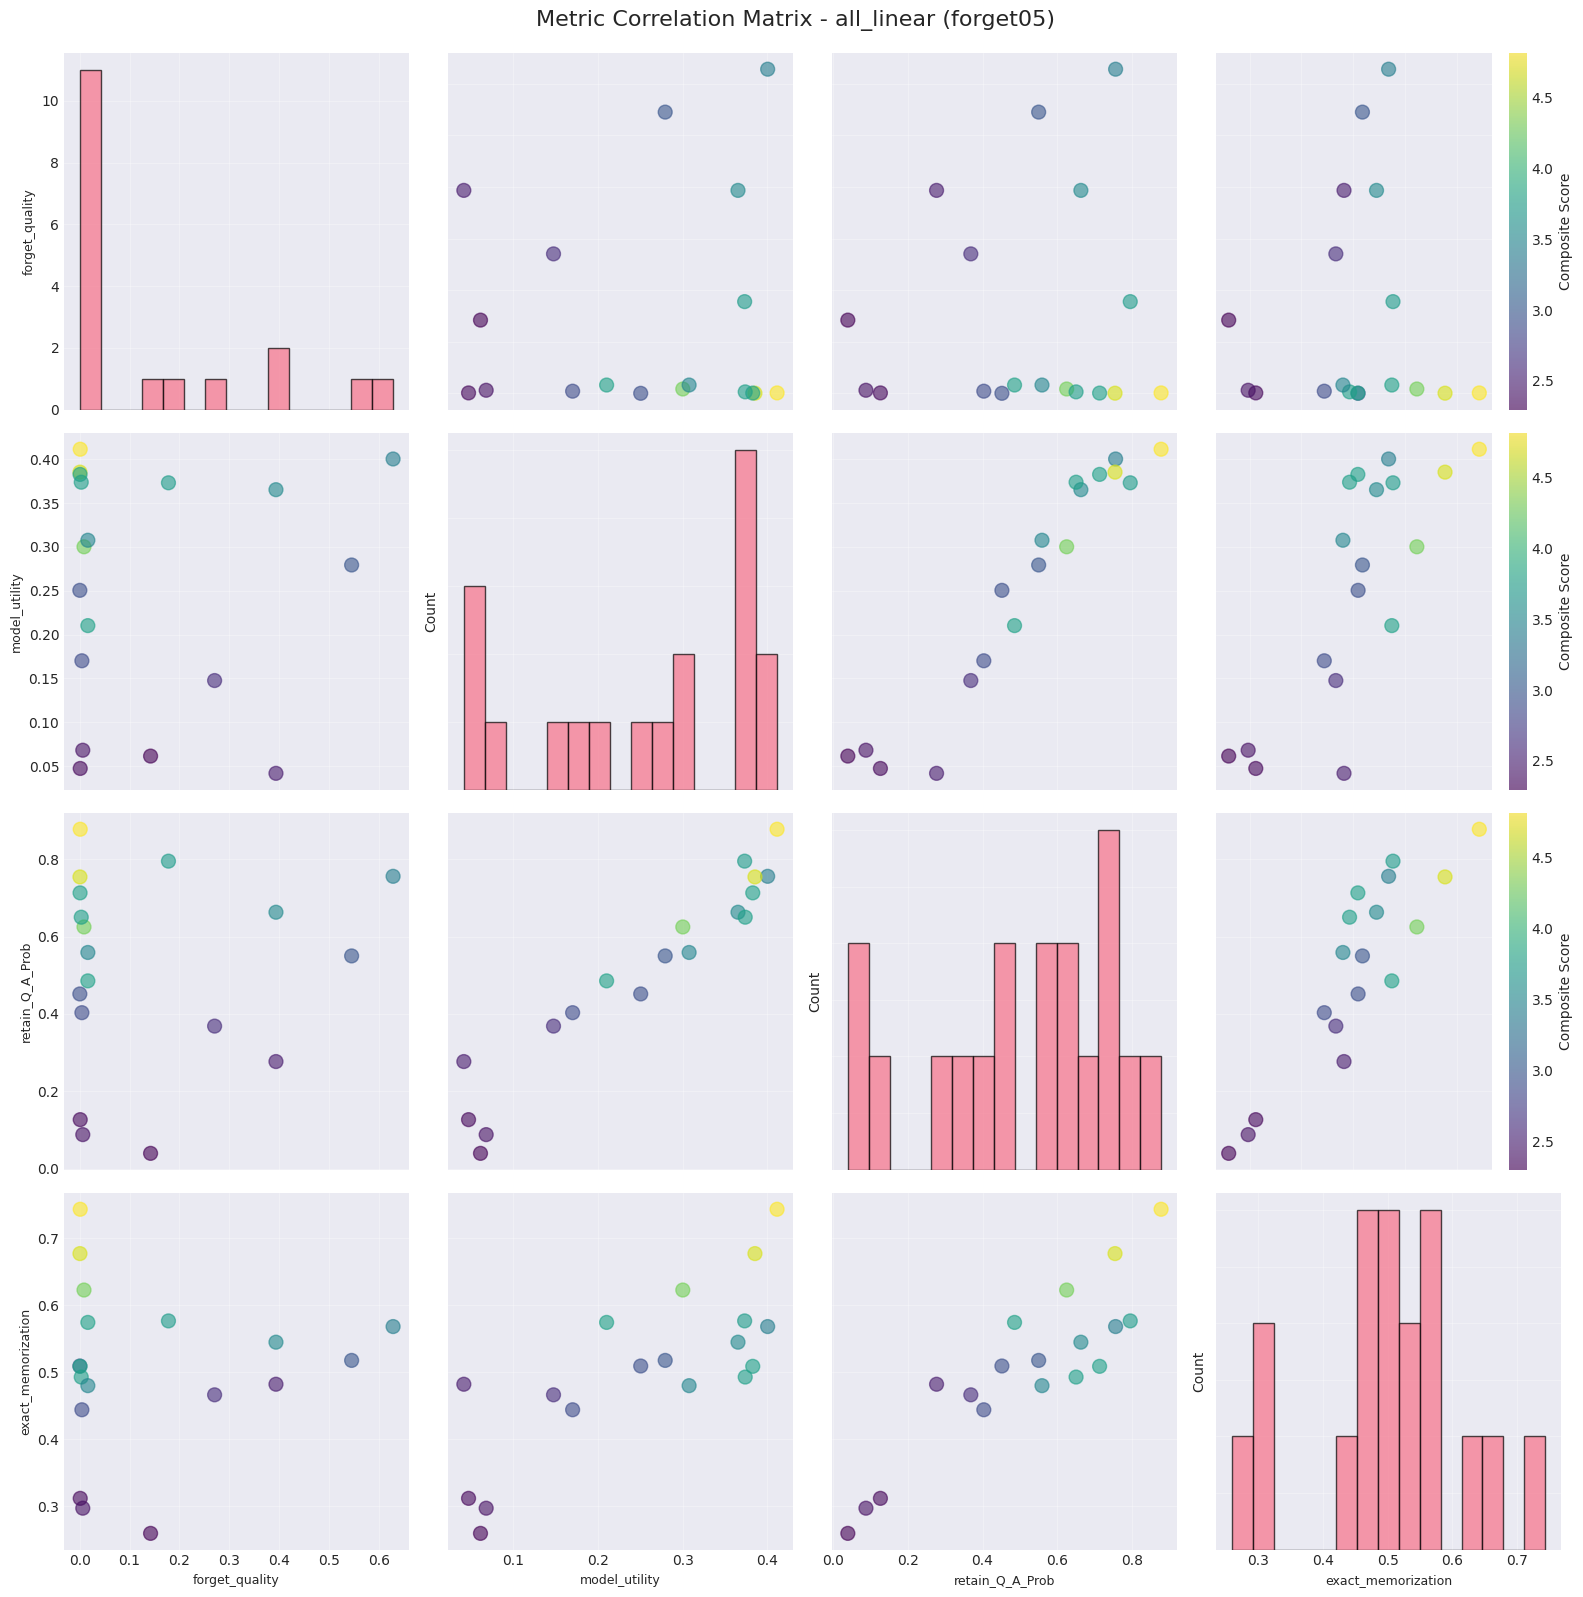

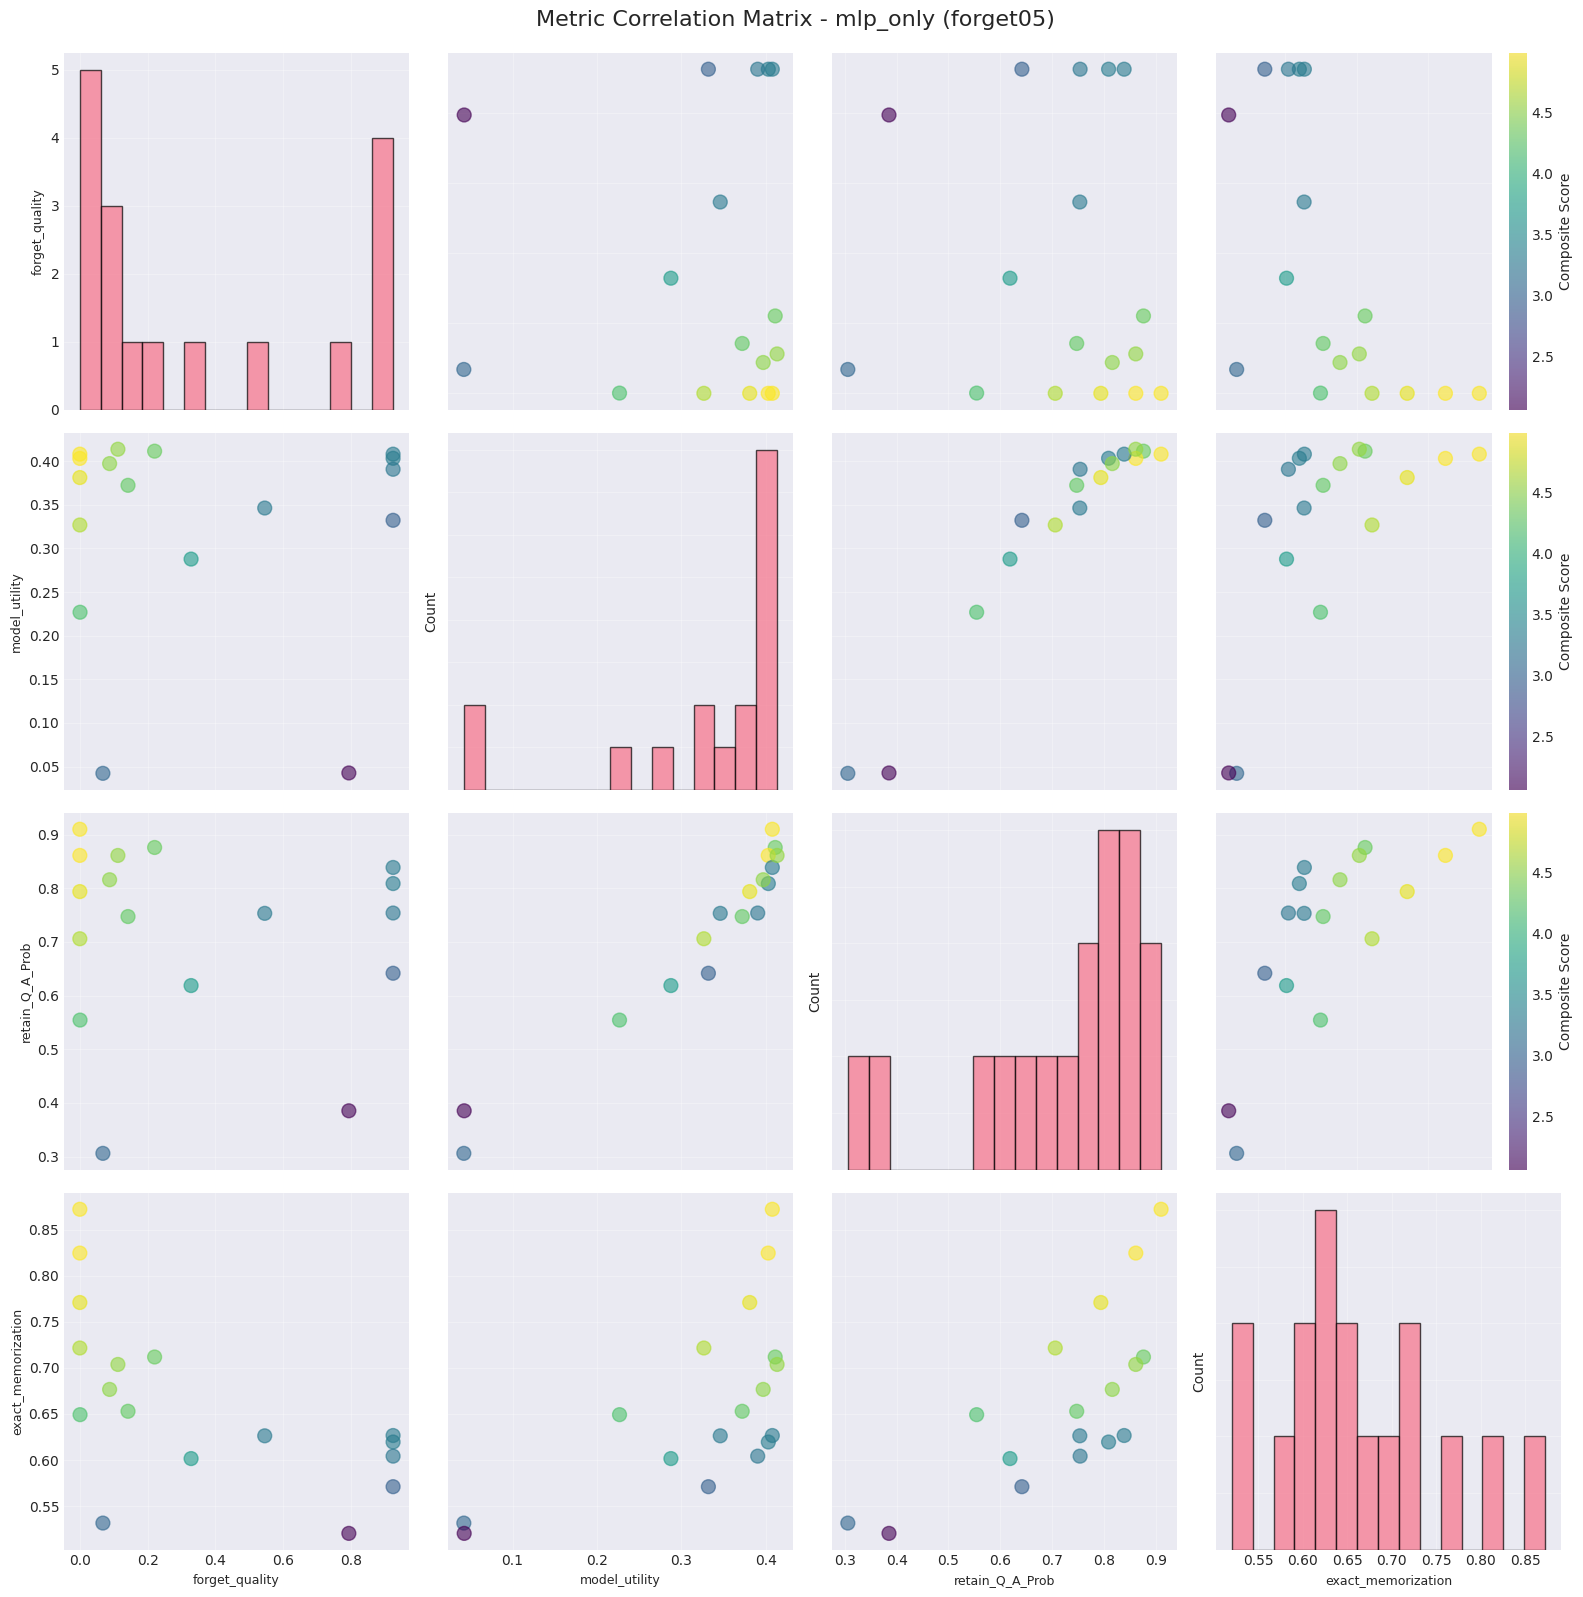

In [ ]:
# 选择几个关键指标进行散点图分析（主要关注择优指标）
scatter_metrics = ['forget_quality', 'model_utility', 'extraction_strength', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE']

# 为每种filter类型创建散点图矩阵
for filter_type in ['all_linear', 'mlp_only']:
    df_filter = df[df['filter_type'] == filter_type].copy()
    
    if len(df_filter) == 0:
        continue
    
    # 创建散点图矩阵
    fig = plt.figure(figsize=(20, 20))
    fig.suptitle(f'Metric Correlation Matrix - {filter_type} (forget05)\n主要择优指标：ES, FQ, MU, ROUGE', 
                 fontsize=16, y=0.995)
    
    n_metrics = len(scatter_metrics)
    
    for i, metric_y in enumerate(scatter_metrics):
        for j, metric_x in enumerate(scatter_metrics):
            ax = plt.subplot(n_metrics, n_metrics, i * n_metrics + j + 1)
            
            if i == j:
                # 对角线显示分布直方图
                ax.hist(df_filter[metric_x], bins=15, alpha=0.7, edgecolor='black')
                ax.set_ylabel('Count')
            else:
                # 非对角线显示散点图
                scatter = ax.scatter(df_filter[metric_x], df_filter[metric_y], 
                                   c=df_filter['composite_score'], cmap='viridis',
                                   alpha=0.6, s=100)
                
                # 只在最右侧列添加colorbar
                if j == n_metrics - 1:
                    plt.colorbar(scatter, ax=ax, label='Composite Score')
            
            # 设置标签
            if i == n_metrics - 1:
                ax.set_xlabel(metric_x, fontsize=8)
            else:
                ax.set_xticklabels([])
            
            if j == 0:
                ax.set_ylabel(metric_y, fontsize=8)
            else:
                ax.set_yticklabels([])
            
            ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 9. 默认配置(α=β=1)的特殊分析


默认配置 (α=1.0, β=1.0) 的性能:
filter_type  forget_quality  model_utility  forget_truth_ratio  retain_Q_A_Prob  exact_memorization   privleak
    default        0.006094       0.381322            0.609546         0.652847            0.499341  10.147870
   mlp_only        0.923837       0.403269            0.603113         0.808648            0.619556 -48.954183
 all_linear        0.003010       0.373735            0.605177         0.650222            0.492729  13.162734


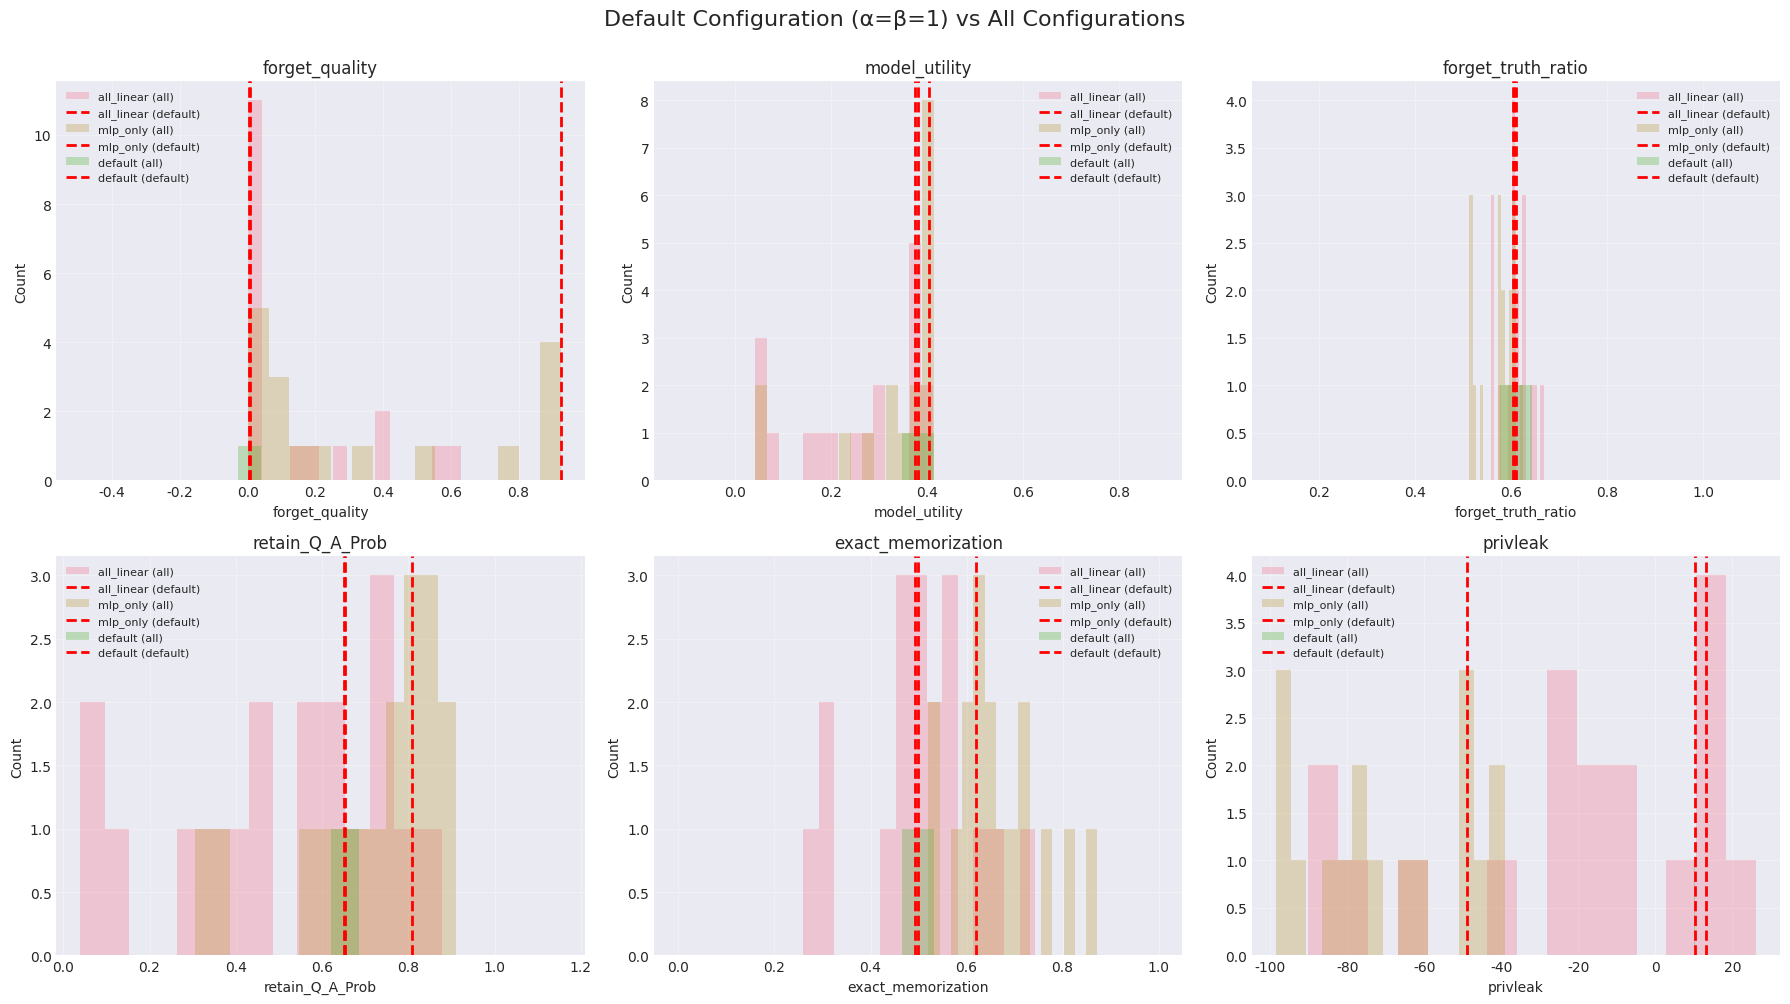


默认配置在各指标中的排名:

Filter类型: default
--------------------------------------------------------------------------------
forget_quality: 1/1 (百分位: 100.0%)
model_utility: 1/1 (百分位: 100.0%)
forget_truth_ratio: 1/1 (百分位: 100.0%)
retain_Q_A_Prob: 1/1 (百分位: 100.0%)
exact_memorization: 1/1 (百分位: 100.0%)
privleak: 1/1 (百分位: 100.0%)

Filter类型: mlp_only
--------------------------------------------------------------------------------
forget_quality: 14/17 (百分位: 82.4%)
model_utility: 5/17 (百分位: 29.4%)
forget_truth_ratio: 14/17 (百分位: 82.4%)
retain_Q_A_Prob: 7/17 (百分位: 41.2%)
exact_memorization: 6/17 (百分位: 35.3%)
privleak: 12/17 (百分位: 70.6%)

Filter类型: all_linear
--------------------------------------------------------------------------------
forget_quality: 6/18 (百分位: 33.3%)
model_utility: 5/18 (百分位: 27.8%)
forget_truth_ratio: 8/18 (百分位: 44.4%)
retain_Q_A_Prob: 7/18 (百分位: 38.9%)
exact_memorization: 8/18 (百分位: 44.4%)
privleak: 16/18 (百分位: 88.9%)


In [ ]:
# 提取默认配置
df_default = df[(df['alpha'] == 1.0) & (df['beta'] == 1.0)].copy()

if len(df_default) > 0:
    print("\n默认配置 (α=1.0, β=1.0) 的性能:")
    print("="*80)
    print(df_default[['filter_type'] + key_metrics].to_string(index=False))
    
    # 与所有配置比较
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.suptitle('Default Configuration (α=β=1) vs All Configurations', fontsize=16, y=0.995)
    
    for idx, metric in enumerate(key_metrics):
        ax = axes[idx // 3, idx % 3]
        
        # 所有配置的分布
        for filter_type in df['filter_type'].unique():
            df_filter = df[df['filter_type'] == filter_type]
            ax.hist(df_filter[metric], alpha=0.3, label=f'{filter_type} (all)', bins=15)
            
            # 标记默认配置
            default_val = df_default[df_default['filter_type'] == filter_type][metric]
            if len(default_val) > 0:
                ax.axvline(default_val.values[0], color='red', linestyle='--', 
                          linewidth=2, label=f'{filter_type} (default)')
        
        ax.set_xlabel(metric)
        ax.set_ylabel('Count')
        ax.set_title(f'{metric}')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    
    # 隐藏多余的子图
    if len(key_metrics) < 9:
        for idx in range(len(key_metrics), 9):
            axes[idx // 3, idx % 3].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 计算默认配置的排名
    print("\n默认配置在各指标中的排名:")
    print("="*80)
    for filter_type in df_default['filter_type'].unique():
        print(f"\nFilter类型: {filter_type}")
        print("-"*80)
        
        df_filter = df[df['filter_type'] == filter_type].copy()
        default_row = df_default[df_default['filter_type'] == filter_type].iloc[0]
        
        for metric in key_metrics:
            # 对于需要最小化的指标，排名越小越好
            if metric in ['forget_Q_A_ROUGE', 'exact_memorization', 'privleak', 'extraction_strength']:
                df_filter[f'{metric}_rank'] = df_filter[metric].rank(method='min')
            else:  # 需要最大化的指标（forget_quality, model_utility, forget_truth_ratio, retain_Q_A_ROUGE）
                df_filter[f'{metric}_rank'] = df_filter[metric].rank(method='min', ascending=False)
            
            total = len(df_filter)
            rank = df_filter[df_filter['alpha'] == 1.0][df_filter['beta'] == 1.0][f'{metric}_rank'].values[0]
            
            # 标记主要择优指标
            marker = " ⭐" if metric in ['extraction_strength', 'forget_quality', 'model_utility', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE'] else ""
            print(f"{metric}: {int(rank)}/{total} (百分位: {(rank/total)*100:.1f}%){marker}")
else:
    print("未找到默认配置的数据")

## 10. 综合分析总结


实验配置统计总结:
Filter Type  Num Configs  forget_quality_mean  forget_quality_std  forget_quality_best  model_utility_mean  model_utility_std  model_utility_best  forget_truth_ratio_mean  forget_truth_ratio_std  forget_truth_ratio_best  retain_Q_A_Prob_mean  retain_Q_A_Prob_std  retain_Q_A_Prob_best  exact_memorization_mean  exact_memorization_std  exact_memorization_best  privleak_mean  privleak_std  privleak_best
 all_linear           18             0.144939            0.209974         1.839576e-04            0.254238           0.134134            0.411332                 0.607571                0.030940                 0.556708              0.510283             0.251299              0.877585                 0.504145                0.124317                 0.259662     -21.522457     36.160338     -90.120288
   mlp_only           17             0.352559            0.389632         4.448674e-08            0.329041           0.119157            0.413654                 0.572992             

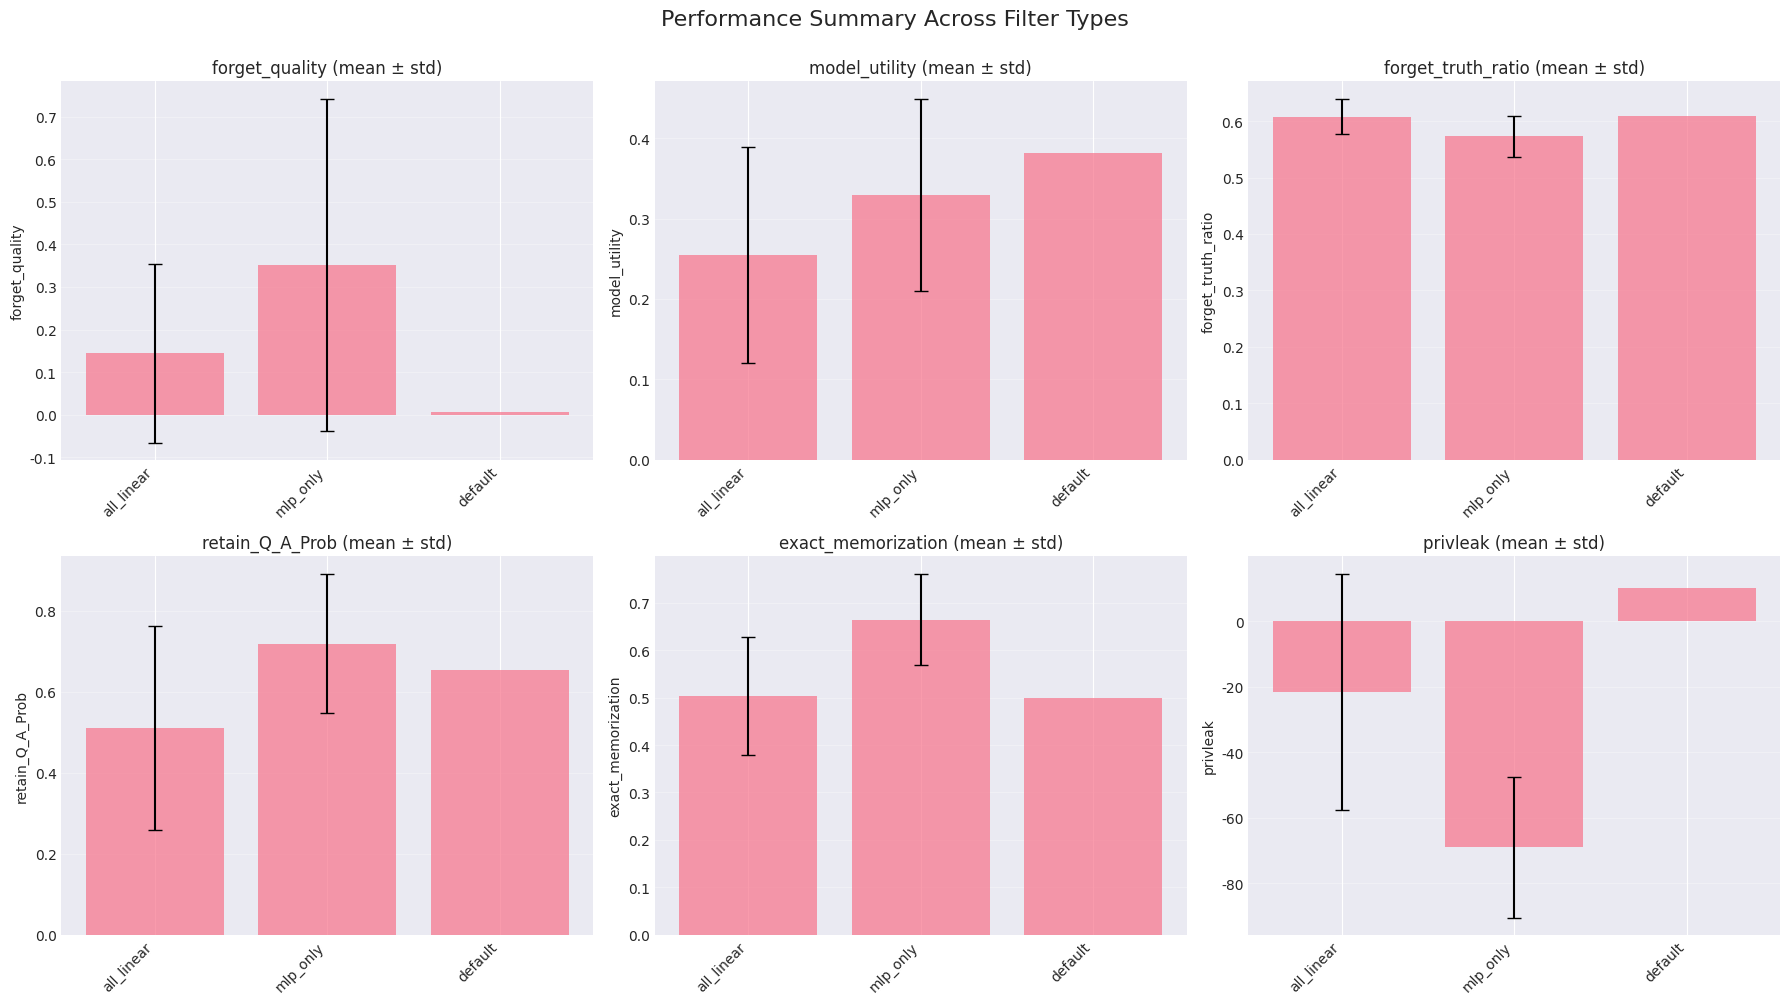


分析完成!


In [ ]:
# 创建综合对比表
summary_stats = []

for filter_type in df['filter_type'].unique():
    df_filter = df[df['filter_type'] == filter_type]
    
    stats = {
        'Filter Type': filter_type,
        'Num Configs': len(df_filter),
    }
    
    for metric in key_metrics:
        stats[f'{metric}_mean'] = df_filter[metric].mean()
        stats[f'{metric}_std'] = df_filter[metric].std()
        # 根据指标方向选择最佳值
        if metric in ['forget_Q_A_ROUGE', 'exact_memorization', 'privleak', 'extraction_strength']:
            stats[f'{metric}_best'] = df_filter[metric].min()
        else:  # forget_quality, model_utility, forget_truth_ratio, retain_Q_A_ROUGE 越高越好
            stats[f'{metric}_best'] = df_filter[metric].max()
    
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)

print("\n实验配置统计总结:")
print("="*100)
print(summary_df.to_string(index=False))

# 可视化综合对比
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
fig.suptitle('Performance Summary Across Filter Types', fontsize=16, y=0.995)

for idx, metric in enumerate(key_metrics):
    ax = axes[idx // 3, idx % 3]
    
    filter_types = summary_df['Filter Type']
    means = summary_df[f'{metric}_mean']
    stds = summary_df[f'{metric}_std']
    
    x_pos = np.arange(len(filter_types))
    bars = ax.bar(x_pos, means, yerr=stds, alpha=0.7, capsize=5)
    
    # 为主要择优指标添加高亮
    if metric in ['extraction_strength', 'forget_quality', 'model_utility', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE']:
        for bar in bars:
            bar.set_edgecolor('red')
            bar.set_linewidth(2)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(filter_types, rotation=45, ha='right')
    ax.set_ylabel(metric)
    
    # 标记主要指标
    title_suffix = " ⭐" if metric in ['extraction_strength', 'forget_quality', 'model_utility', 'forget_Q_A_ROUGE', 'retain_Q_A_ROUGE'] else ""
    ax.set_title(f'{metric} (mean ± std){title_suffix}')
    ax.grid(True, alpha=0.3, axis='y')

# 隐藏多余的子图
if len(key_metrics) < 9:
    for idx in range(len(key_metrics), 9):
        axes[idx // 3, idx % 3].axis('off')

plt.tight_layout()
plt.show()

print("\n分析完成!")
print("⭐标记表示参数择优的主要考虑指标（ES, FQ, MU, ROUGE）")

## 11. 导出分析结果

In [ ]:
# 保存完整数据到CSV
output_path = BASE_DIR / 'forget05_detailed_analysis.csv'
df.to_csv(output_path, index=False)
print(f"详细分析数据已保存到: {output_path}")

# 保存最佳配置
best_configs_path = BASE_DIR / 'forget05_best_configs.csv'
best_configs = df.nlargest(10, 'composite_score')[['exp_name', 'filter_type', 'alpha', 'beta', 'composite_score'] + key_metrics]
best_configs.to_csv(best_configs_path, index=False)
print(f"最佳配置已保存到: {best_configs_path}")

print("\n所有分析完成!")

详细分析数据已保存到: /cnz/data/project/my-open-unlearning/saves/tvc_results/forget05_detailed_analysis.csv
最佳配置已保存到: /cnz/data/project/my-open-unlearning/saves/tvc_results/forget05_best_configs.csv

所有分析完成!
